# Limpieza DateSet - LaClosa

## Concatenación

Primero asegurar que no hay años erroneos en 2023

In [ ]:
import os
import pandas as pd

base_path = r"C:\Users\USUARIO\Desktop\TFG"
carpeta = os.path.join(base_path, "2023")

años_correctos = True  

for mes in range(1, 13):

    nombre = f"historico_graficas_2023_{mes}.csv"
    ruta = os.path.join(carpeta, nombre)

    if not os.path.exists(ruta):
        continue

    df = pd.read_csv(ruta, sep=",")

    # Convertir instante a fecha
    df['instante'] = pd.to_datetime(df['instante'], errors='coerce')

    # Si hay algún año distinto de 2023 → False
    if not (df['instante'].dt.year == 2023).all():
        años_correctos = False
        break

print(años_correctos)


True


Unificar los 4 años en un solo dataset, modificar magnitudes, renombrar variables y eliminar variables extra

In [ ]:
import os
import pandas as pd

base_path = r"C:\Users\USUARIO\Desktop\TFG"

años = ['2020', '2021', '2022', '2023']

goteros_info = {
    1: {"goteros_linea": 20, "goteros_arbol": 4},
    2: {"goteros_linea": 22, "goteros_arbol": 6},
    3: {"goteros_linea": 15, "goteros_arbol": 4},
    4: {"goteros_linea": 20, "goteros_arbol": 4},
    5: {"goteros_linea": 30, "goteros_arbol": 3},
    6: {"goteros_linea": 12, "goteros_arbol": 4},
    7: {"goteros_linea": 16, "goteros_arbol": 6},
    8: {"goteros_linea": 13, "goteros_arbol": 4},
}

columnas_deseadas = ['id_nodo', 'instante'] + [f'var{i}' for i in range(1, 12) if i != 10]

df_list = []


# RECORRER AÑOS Y MESES
for año in años:
    carpeta = os.path.join(base_path, año)
    if not os.path.isdir(carpeta):
        print(f"No existe la carpeta: {carpeta}")
        continue

    for mes in range(1, 13):
        if año in ['2020', '2021']:
            nombre = f"historico_graficas_{año}_{mes:02d}.csv"
        else:
            nombre = f"historico_graficas_{año}_{mes}.csv"

        ruta = os.path.join(carpeta, nombre)

        if not os.path.exists(ruta):
            print(f"No encontrado: {ruta}")
            continue

        print(f"Leyendo: {ruta}")
        df = pd.read_csv(ruta, sep=",")

        columnas_presentes = [c for c in columnas_deseadas if c in df.columns]
        df = df[columnas_presentes]

        df["instante"] = pd.to_datetime(df["instante"], errors="coerce")

        # Escalar humedad
        humedad_vars = ["var1", "var2", "var3", "var4", "var5", "var6", "var9"]
        for col in humedad_vars:
            if col in df.columns:
                df[col] = df[col] / 10000

        # Escalar temperatura
        temperatura_vars = ["var7", "var8"]
        for col in temperatura_vars:
            if col in df.columns:
                df[col] = df[col] / 100

        # Añadir goteros_linea
        df["goteros_linea"] = df["id_nodo"].map(lambda x: goteros_info[x]["goteros_linea"])

        # Calcular litros por árbol
        df["litros_arbol"] = df.apply(
            lambda row: (row["var11"] / goteros_info[row["id_nodo"]]["goteros_linea"])
                        * goteros_info[row["id_nodo"]]["goteros_arbol"],
            axis=1
        )

        # Selección de columnas finales
        columnas_finales = [
            "id_nodo", "instante",
            "var1", "var2", "var3", "var4", "var5", "var6",
            "var7", "var8", "var9",
            "litros_arbol"
        ]

        df = df[columnas_finales]

        # Renombrado final
        renombrar_columnas = {
            "var1": "HS10",
            "var2": "HS20",
            "var3": "HS30",
            "var4": "HS40",
            "var5": "HS50",
            "var6": "HS60",
            "var7": "TS30",
            "var8": "TA",
            "var9": "HA",
        }

        df.rename(columns=renombrar_columnas, inplace=True)

        df_list.append(df)

if df_list:
    df_final = pd.concat(df_list, ignore_index=True)

    output_path = os.path.join(base_path, "datosMurcia.csv")
    df_final.to_csv(output_path, index=False)

    print(f"\nArchivo final generado en: {output_path}")
    print(f"Total de registros: {len(df_final)}")
else:
    print("No se encontraron datos válidos para concatenar.")


Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_01.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_02.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_03.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_04.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_05.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_06.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_07.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_08.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_09.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_10.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_11.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2020\historico_graficas_2020_12.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\2021\historico_graficas_2021_01.csv
Leyendo: C:\Users\USUARIO\Desktop\TFG\

In [ ]:
import pandas as pd
import os

base_path = r"C:\Users\USUARIO\Desktop\TFG"
ruta = os.path.join(base_path, "datosLC.csv")

df = pd.read_csv(ruta)

print(df.head(10))


   id_nodo             instante    HS10    HS20    HS30    HS40    HS50  \
0        1  2020-01-01 00:06:44  0.6765  0.6893  0.7323  0.6917  0.7067   
1        1  2020-01-01 00:16:01  0.6765  0.6892  0.7323  0.6919  0.7067   
2        1  2020-01-01 00:25:11  0.6765  0.6892  0.7323  0.6915  0.7064   
3        1  2020-01-01 00:34:42  0.6767  0.6889  0.7323  0.6915  0.7064   
4        1  2020-01-01 00:44:13  0.6767  0.6892  0.7320  0.6917  0.7066   
5        1  2020-01-01 00:54:12  0.6767  0.6889  0.7320  0.6917  0.7067   
6        1  2020-01-01 01:03:29  0.6765  0.6889  0.7320  0.6917  0.7064   
7        1  2020-01-01 01:13:22  0.6762  0.6889  0.7320  0.6917  0.7066   
8        1  2020-01-01 01:22:06  0.6762  0.6889  0.7320  0.6917  0.7064   
9        1  2020-01-01 01:51:06  0.6761  0.6889  0.7318  0.6917  0.7064   

     HS60  TS30     TA      HA  litros_arbol  
0  0.7020  12.5 -20.04  0.1306        9563.4  
1  0.7017  12.5 -20.04  0.1306        9563.4  
2  0.7017  12.5 -20.04  0.1306   

NODE 2 SELECTION JUSTIFIED

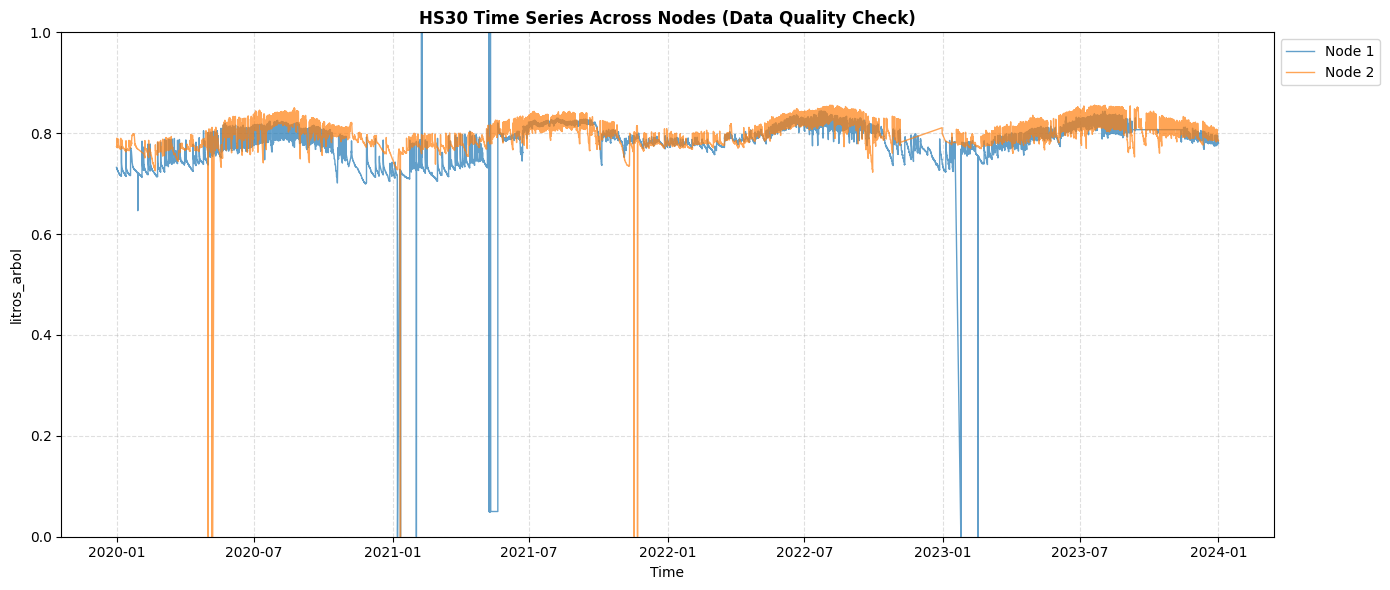

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_path = r"C:\Users\USUARIO\Desktop\TFG\csv"
ruta = os.path.join(base_path, "datosLC.csv")

df = pd.read_csv(ruta)

df['instante'] = pd.to_datetime(df['instante'])

# Orden temporal
df = df.sort_values('instante')

plt.figure(figsize=(14,6))

for node, g in df.groupby('id_nodo'):
    if node in [1,2]:
        plt.plot(g['instante'], g['HS30'],
                label=f'Node {node}',
                alpha=0.7,
                linewidth=1)

plt.title('HS30 Time Series Across Nodes (Data Quality Check)', fontweight='bold')
plt.xlabel('Time')
plt.ylabel('litros_arbol')
plt.ylim(0,1)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()

plt.show()

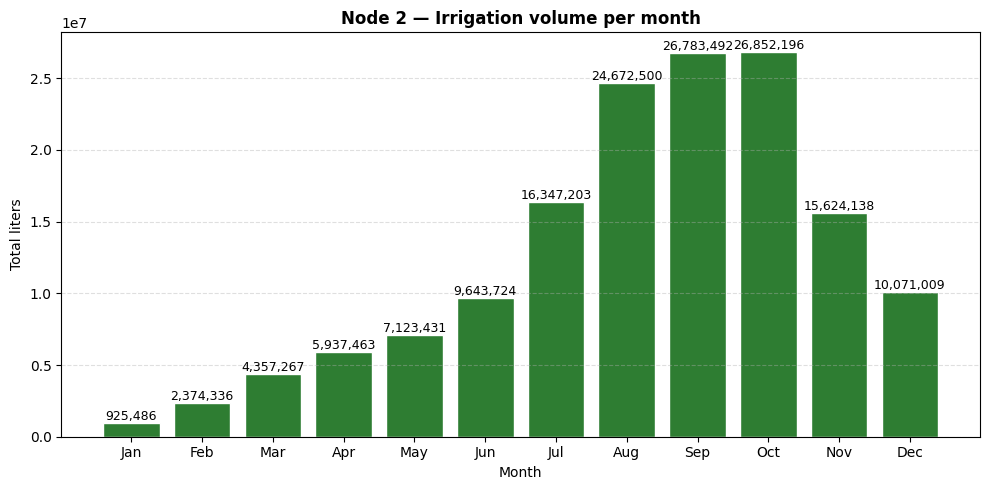

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_path = r"C:\Users\USUARIO\Desktop\TFG\csv"
ruta = os.path.join(base_path, "datosLC.csv")

df = pd.read_csv(ruta)
df['instante'] = pd.to_datetime(df['instante'])
df['Month'] = df['instante'].dt.month
df['Hour'] = df['instante'].dt.floor('h')


df2 = df[df['id_nodo'] == 2]
df_riego = df2[df2['litros_arbol'] > 0]

liters_month = df_riego.groupby('Month')['litros_arbol'].sum().reindex(range(1,13), fill_value=0)

plt.figure(figsize=(10,5))

plt.bar(liters_month.index, liters_month.values,
        color='#2E7D32', edgecolor='white')

for x, y in liters_month.items():
    plt.text(x, y, f'{int(y):,}', ha='center', va='bottom', fontsize=9)

plt.xticks(range(1,13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.title('Node 2 — Irrigation volume per month', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total liters')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(base_path, 'node2_irrigation_liters_month.png'), dpi=150)
plt.show()

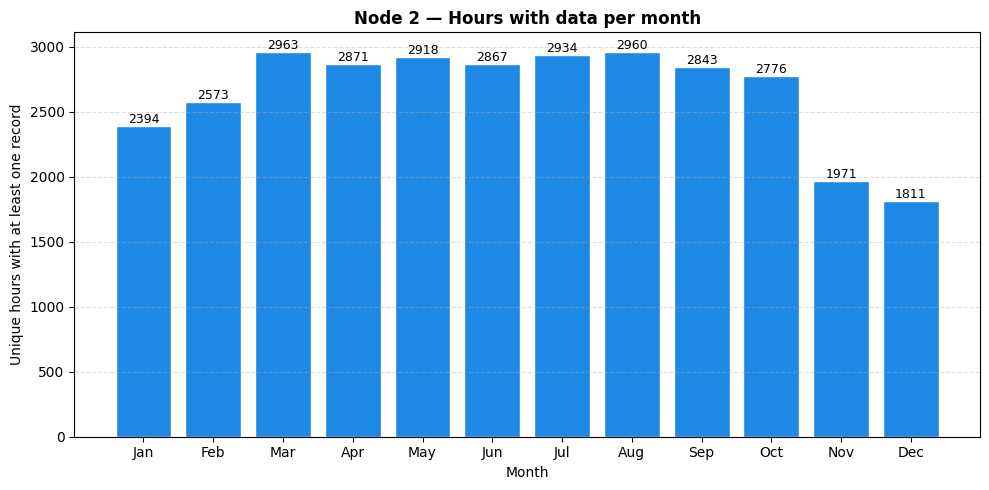

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

base_path = r"C:\Users\USUARIO\Desktop\TFG\csv"
ruta = os.path.join(base_path, "datosLC.csv")

df = pd.read_csv(ruta)

df['instante'] = pd.to_datetime(df['instante'])
df['Month'] = df['instante'].dt.month

# Crear hora única
df['Hour'] = df['instante'].dt.floor('h')

df2 = df[df['id_nodo'] == 2]

hours_month = (
    df2.groupby('Month')['Hour']
    .nunique()
    .reindex(range(1,13), fill_value=0)
)

plt.figure(figsize=(10,5))

plt.bar(hours_month.index, hours_month.values,
        color='#1E88E5', edgecolor='white')

for x, y in hours_month.items():
    plt.text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=9)

plt.xticks(range(1,13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.title('Node 2 — Hours with data per month', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Unique hours with at least one record')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(base_path, 'node2_hours_with_data_month.png'), dpi=150)
plt.show()

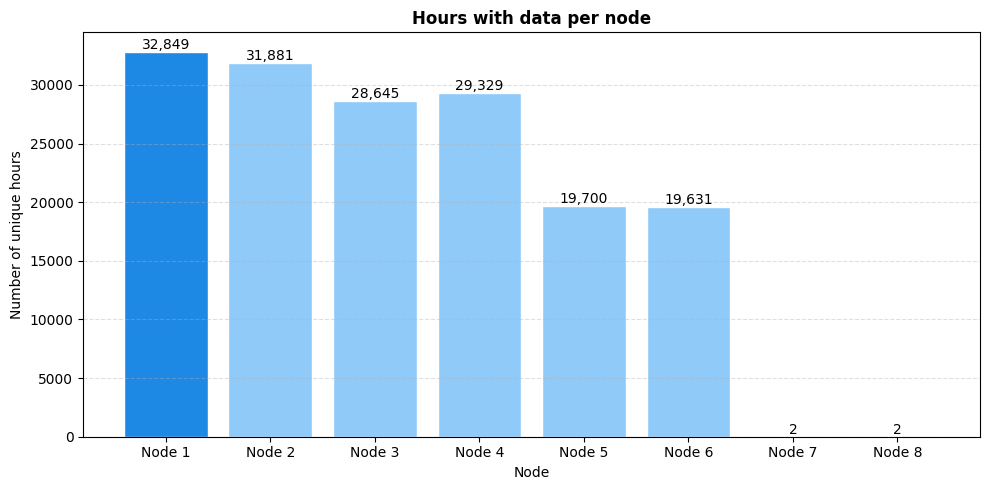

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

base_path = r"C:\Users\USUARIO\Desktop\TFG\csv"
ruta = os.path.join(base_path, "datosLC.csv")

df = pd.read_csv(ruta)
df['instante'] = pd.to_datetime(df['instante'])

# Redondear a hora
df['Hour'] = df['instante'].dt.floor('h')
results = []

for node, g in df.groupby('id_nodo'):

    hours = g['Hour'].nunique()

    results.append({
        'Node': f'Node {node}',
        'id_nodo': node,
        'Hours with data': hours
    })

df_plot = pd.DataFrame(results).sort_values('id_nodo')

plt.figure(figsize=(10,5))

max_idx = df_plot['Hours with data'].idxmax()

colors = ['#1E88E5' if i == max_idx else '#90CAF9'
          for i in range(len(df_plot))]

bars = plt.bar(df_plot['Node'],
               df_plot['Hours with data'],
               color=colors,
               edgecolor='white')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h,
             f'{int(h):,}',
             ha='center', va='bottom', fontsize=10)

plt.title('Hours with data per node', fontweight='bold')
plt.ylabel('Number of unique hours')
plt.xlabel('Node')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(base_path, 'hours_with_data_nodes.png'), dpi=150)
plt.show()

Seleccionar nodo de interés (id_nodo=2)

In [ ]:
import pandas as pd

ruta = r"C:\Users\USUARIO\Desktop\TFG\datosLC.csv"
df = pd.read_csv(ruta)

# Filtrar nodo 2
df_nodo2 = df[df["id_nodo"] == 2].copy()
df_nodo2 = df_nodo2.sort_values("instante").reset_index(drop=True)

ruta_salida = r"C:\Users\USUARIO\Desktop\TFG\LaClosa2.csv"
df_nodo2.to_csv(ruta_salida, index=False)

print("CSV LaClosa2.csv creado correctamente.")


## Identificación Anómalos

### Variable H

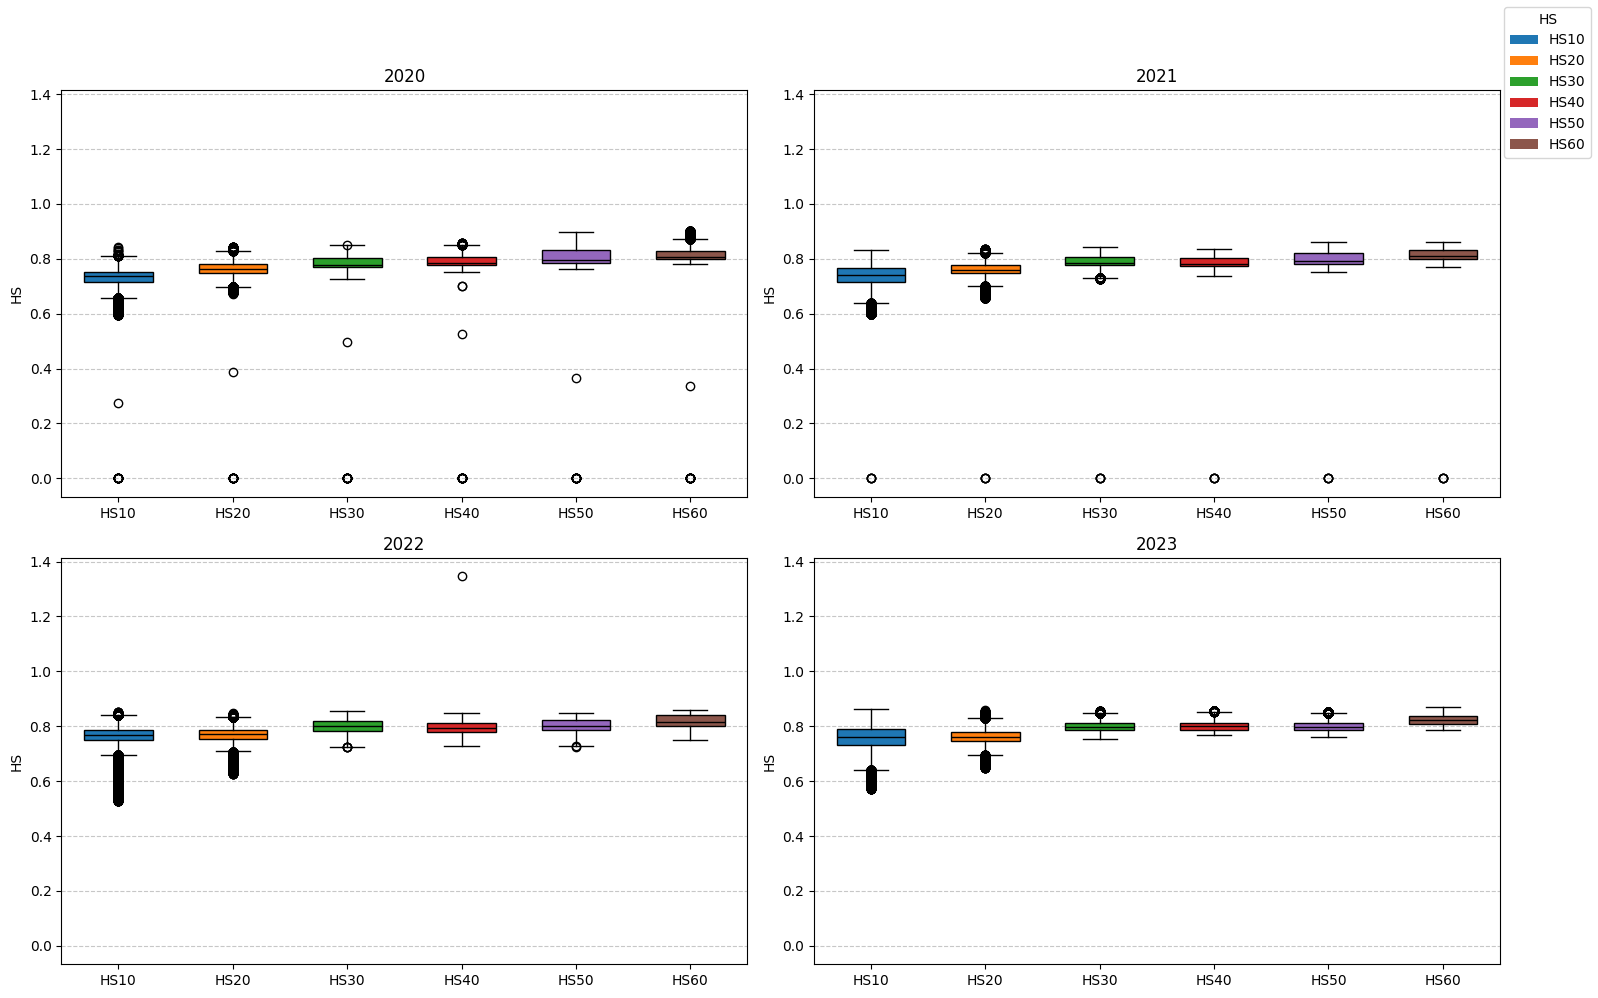

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ruta = r"C:\Users\USUARIO\Desktop\TFG\csv\LaClosa2.csv"
df = pd.read_csv(ruta)

df["instante"] = pd.to_datetime(df["instante"], errors="coerce")
df = df.dropna(subset=["instante"])
df["año"] = df["instante"].dt.year


hs_columns = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]
años = sorted(df["año"].unique())
colores = ["C0", "C1", "C2", "C3", "C4", "C5"]  

y_min = df[hs_columns].min().min()
y_max = df[hs_columns].max().max()

y_range = y_max - y_min
y_min_plot = y_min - 0.05 * y_range
y_max_plot = y_max + 0.05 * y_range

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()  

for ax, año in zip(axes, años):
    datos = [df[df["año"] == año][col] for col in hs_columns]
    
    box = ax.boxplot(datos, patch_artist=True, widths=0.6,
                     medianprops=dict(color='black'))
    
    for patch, color in zip(box['boxes'], colores):
        patch.set_facecolor(color)
    
    ax.set_title(f"{año}")
    ax.set_xticks(range(1, len(hs_columns)+1))
    ax.set_xticklabels(hs_columns)
    ax.set_ylabel("HS")
    ax.set_ylim(y_min_plot, y_max_plot)  # Misma escala con margen
    ax.grid(axis="y", linestyle="--", alpha=0.7)

fig.legend([Patch(facecolor=c) for c in colores], hs_columns, title="HS", loc="upper right")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])  
plt.show()


HS10 y HS20 más anomalías a primera vista

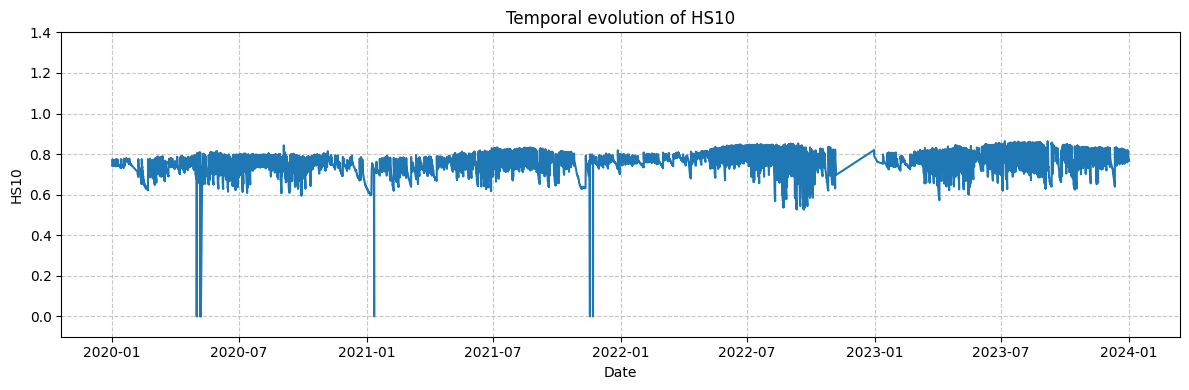

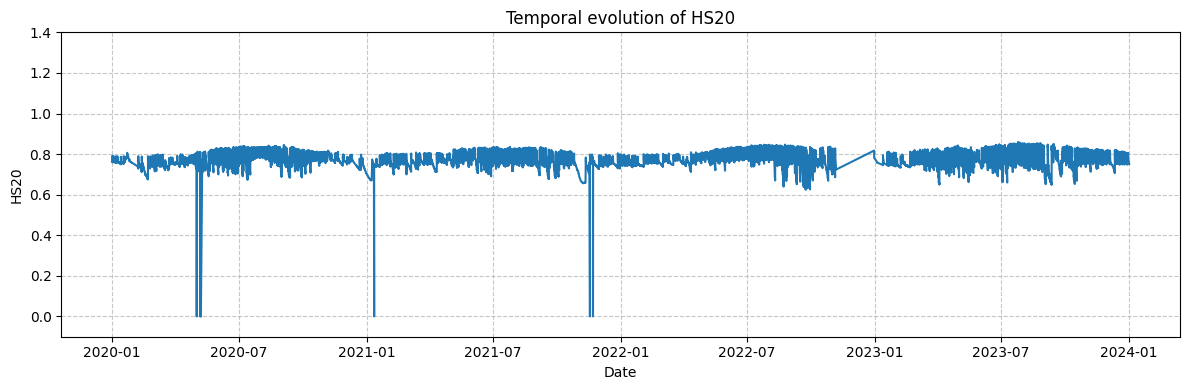

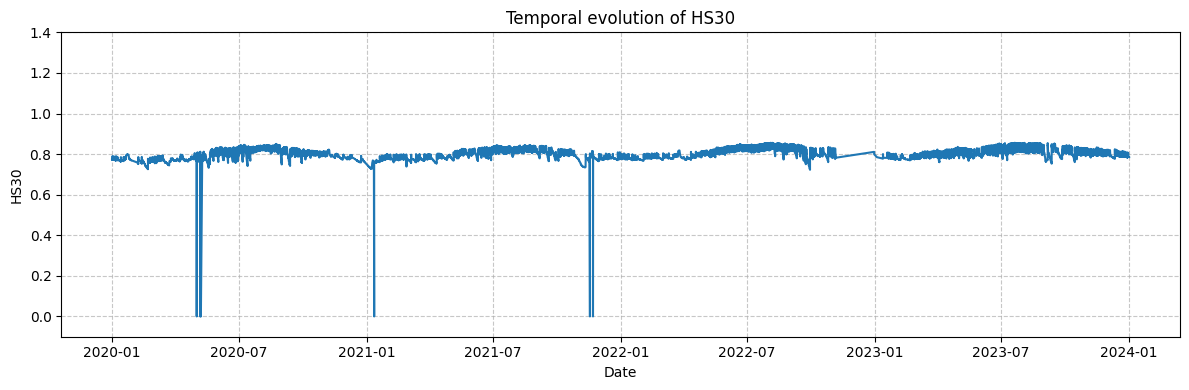

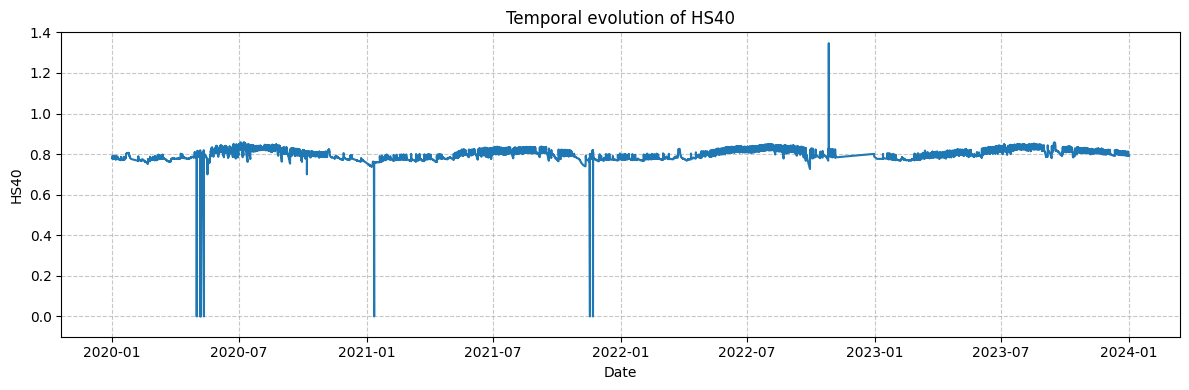

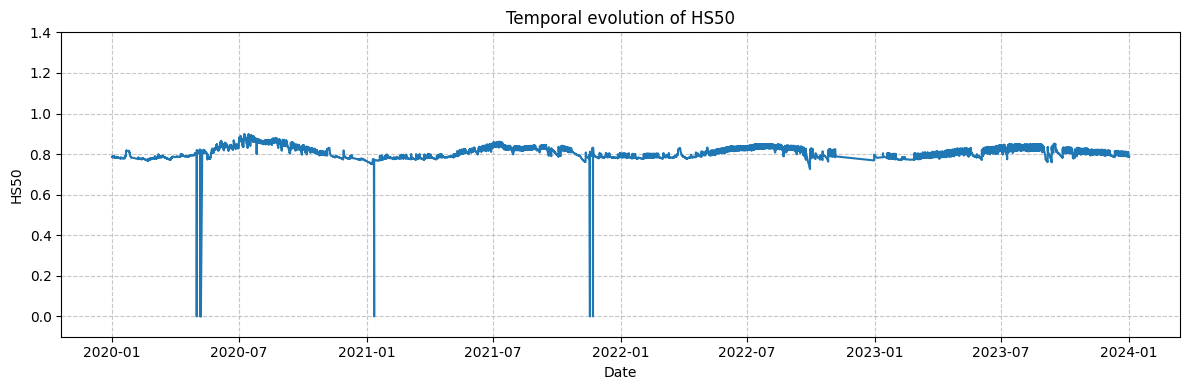

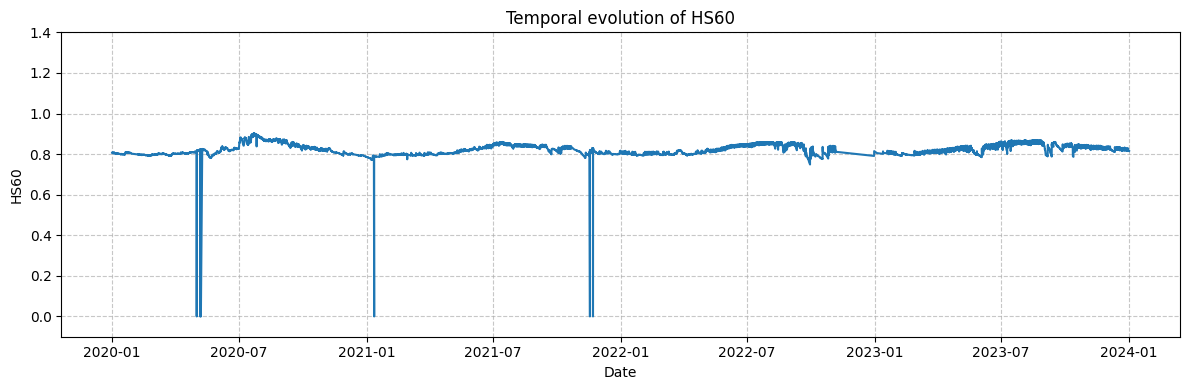

In [97]:
import matplotlib.pyplot as plt

hs_columns = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

for col in hs_columns:
    plt.figure(figsize=(12, 4))
    plt.plot(df["instante"], df[col], linestyle='-')
    plt.title(f"Temporal evolution of {col}")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.ylim(-0.1,1.4)
    plt.savefig(f"images/ts{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

#### N1-A-Fuera de rango 

In [98]:
import pandas as pd

hs_columns = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

# Limitar valores de HS10-HS60 a 0.15 - 1 
for col in hs_columns:
    fuera_rango = (~df[col].between(0.15, 1)).sum()
    print(f"{col}: {fuera_rango} valores fuera de rango")
    df[col] = df[col].where(df[col].between(0.15, 1), other=pd.NA)

HS10: 17 valores fuera de rango
HS20: 17 valores fuera de rango
HS30: 17 valores fuera de rango
HS40: 19 valores fuera de rango
HS50: 17 valores fuera de rango
HS60: 17 valores fuera de rango


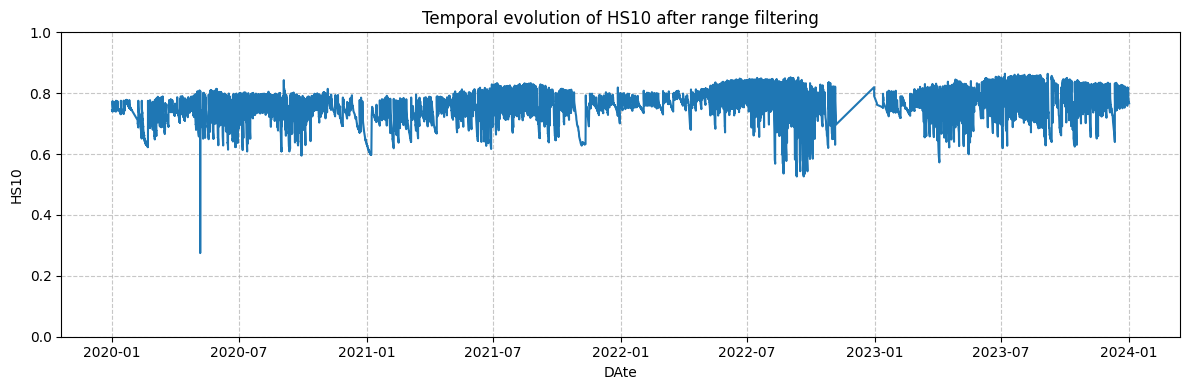

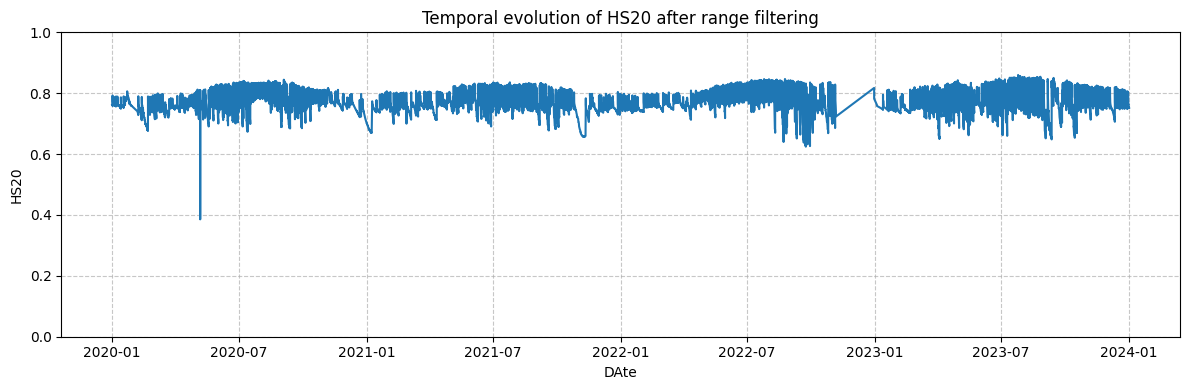

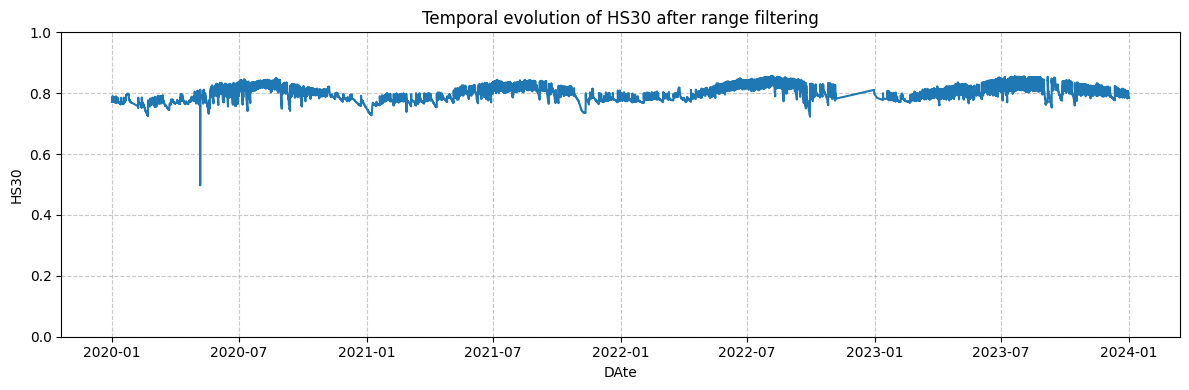

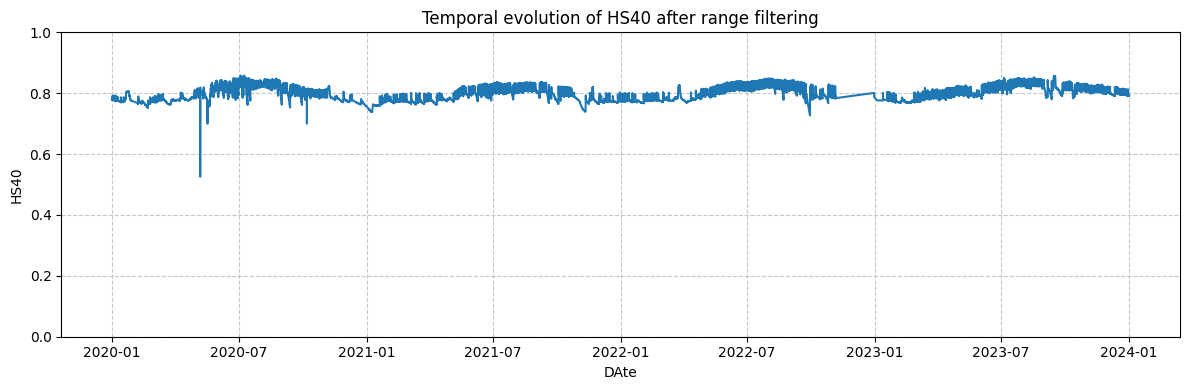

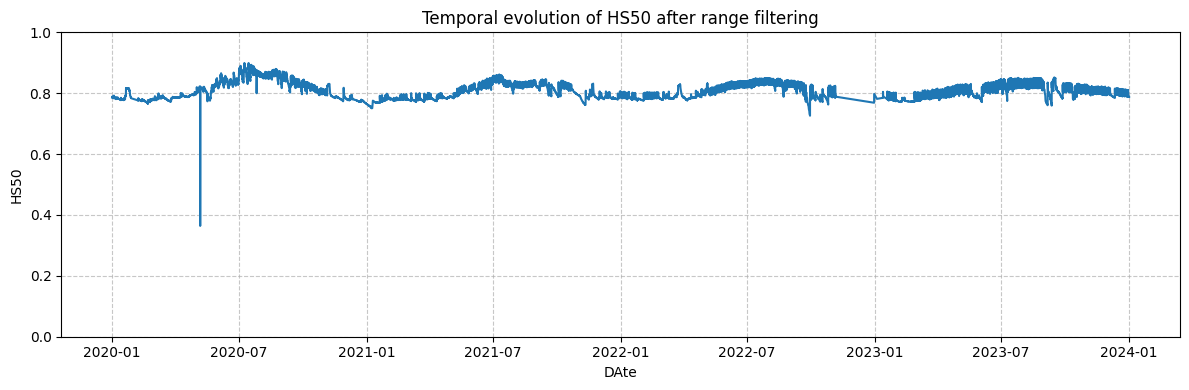

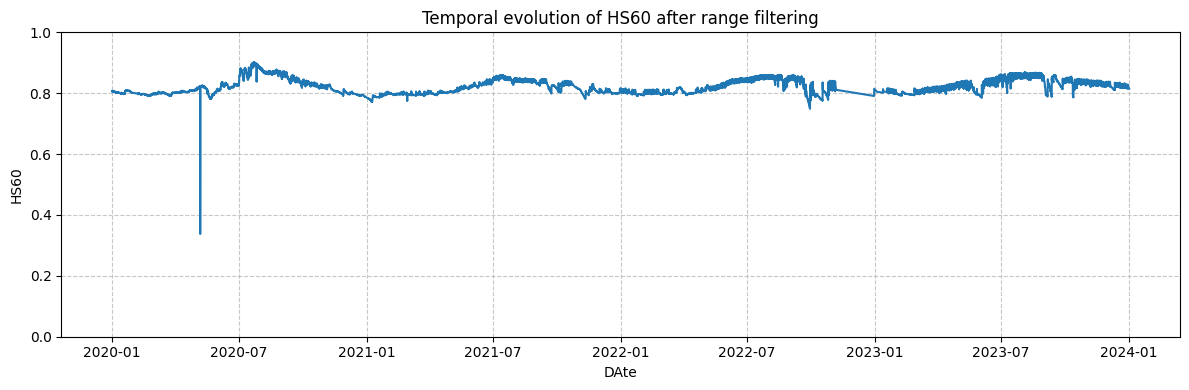

In [99]:
import matplotlib.pyplot as plt
hs_columns = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

for col in hs_columns:
    plt.figure(figsize=(12, 4))
    plt.plot(df["instante"], df[col], linestyle='-')
    plt.title(f"Temporal evolution of {col} after range filtering")
    plt.xlabel("DAte")
    plt.ylabel(col)
    plt.ylim(0,1)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"images/tsrange{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

#### N1-C-Picos en mediciones consecutivas

In [ ]:
import pandas as pd
import numpy as np

hs_columns = [col for col in df.columns if col.startswith("HS")]

spikes_por_variable = {}

for col in hs_columns:
    serie = df[col]

    # Calcular IQR
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    # Detectar spikes: diferencia > x*IQR
    diffs = serie.diff().abs()
    spikes = diffs > iqr*5

    spikes_por_variable[col] = spikes.sum()

    df.loc[spikes, col] = np.nan

print("Número de spikes eliminados (puestos a NaN) — K = 1 IQR:")
for col, n in spikes_por_variable.items():
    print(f"{col}: {n}")


Número de spikes eliminados (puestos a NaN) — K = 1 IQR:
HS10: 8
HS20: 9
HS30: 2
HS40: 2
HS50: 2
HS60: 2


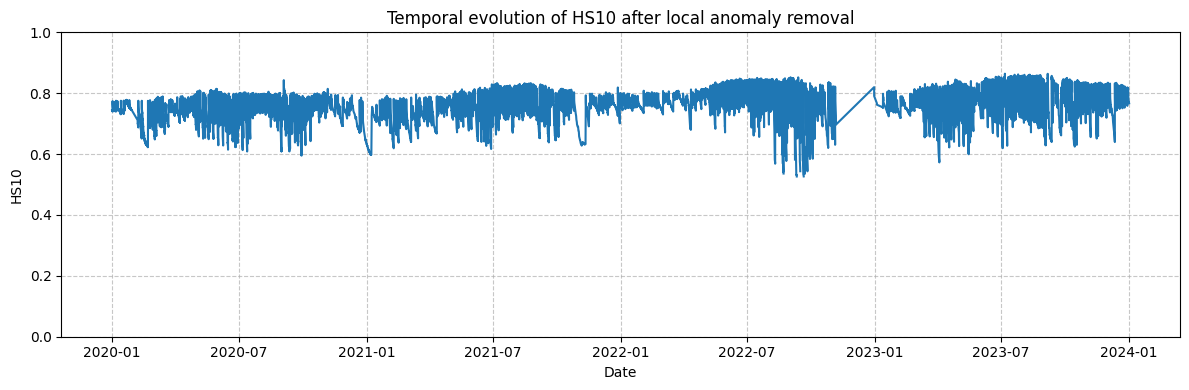

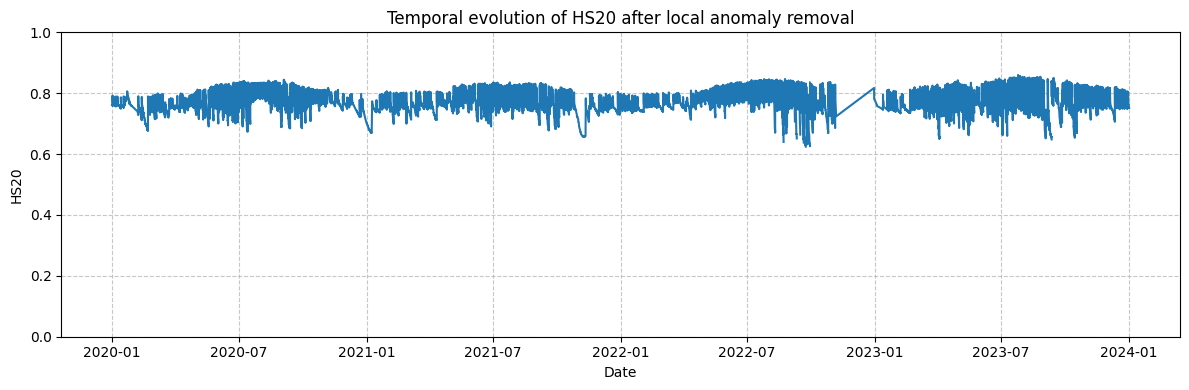

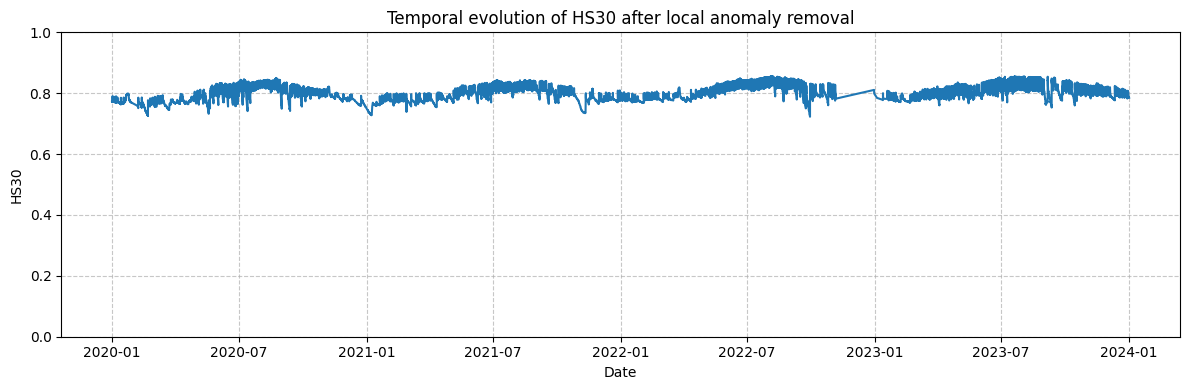

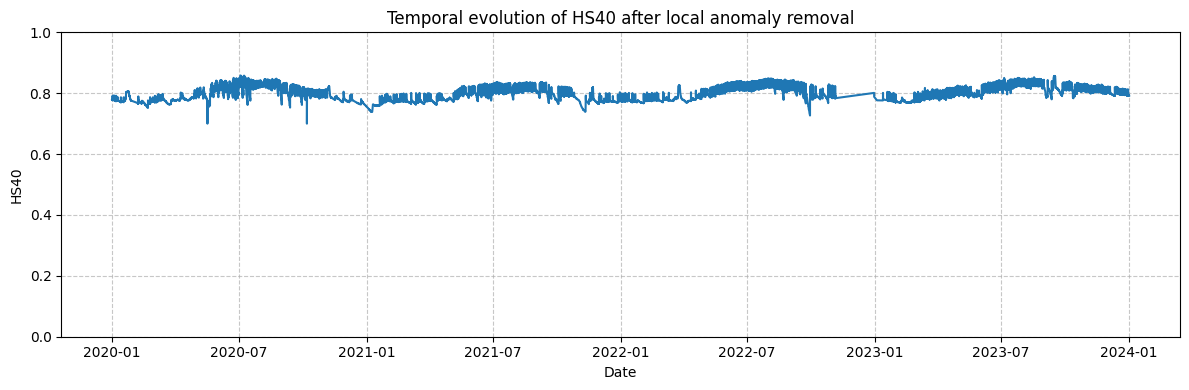

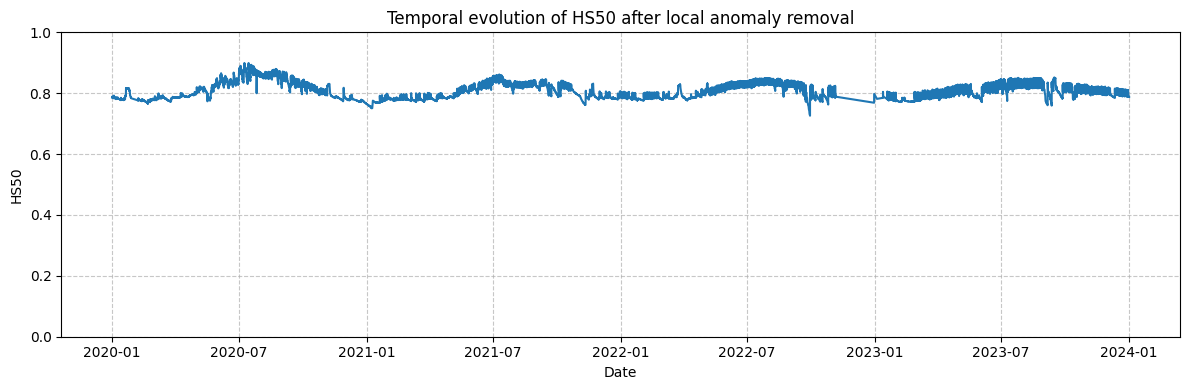

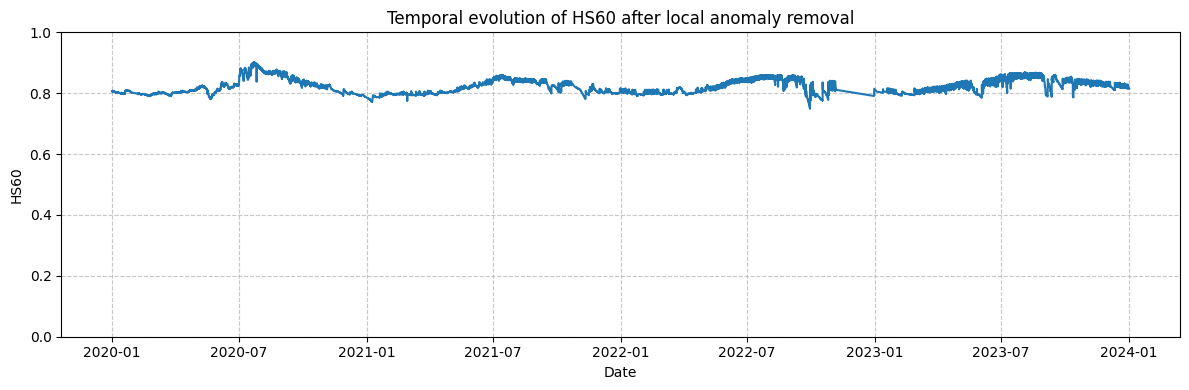

In [101]:
import matplotlib.pyplot as plt
hs_columns = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

for col in hs_columns:
    plt.figure(figsize=(12, 4))
    plt.plot(df["instante"], df[col], linestyle='-')
    plt.title(f"Temporal evolution of {col} after local anomaly removal")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.ylim(0,1)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"images/tslocal{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

A mayor profundidad menos picos

### HA

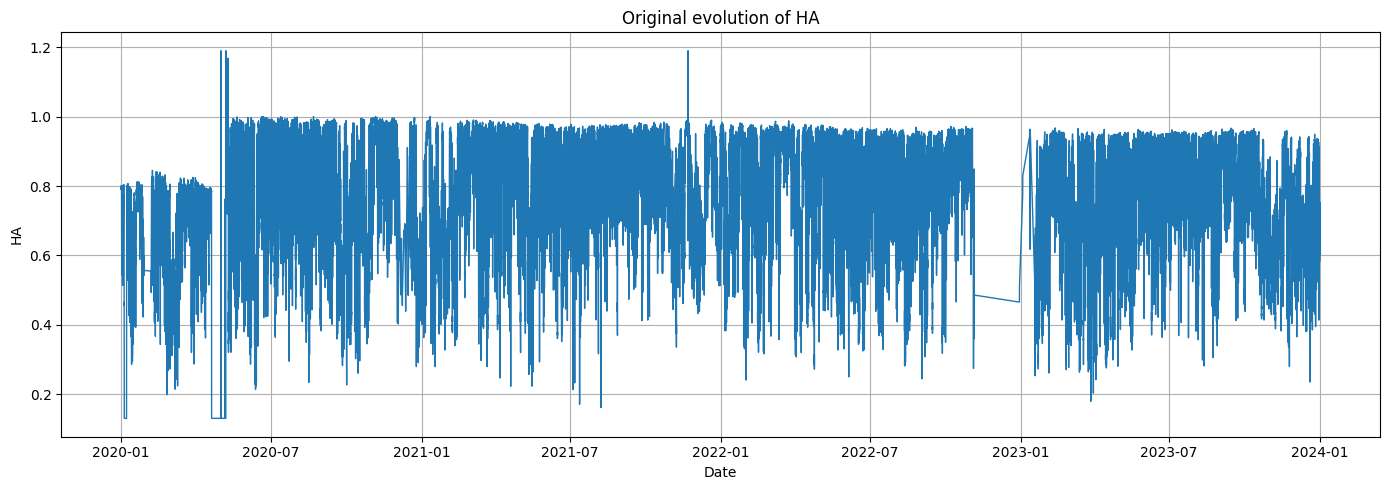

In [107]:
import matplotlib.pyplot as plt
df.index = pd.to_datetime(df.index)

plt.figure(figsize=(14,5))
plt.plot(df['instante'], df["HA"], linewidth=1)

plt.title("Original evolution of HA")
plt.xlabel("Date")
plt.ylabel("HA")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"images/HAori.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
mask_invalid = (df["HA"] > 1) | (df["HA"] < 0.25)
num_invalid = mask_invalid.sum()

print(f"Valores de HA fuera del rango [0.25, 1]: {num_invalid}")

df["HA"] = df["HA"].mask(mask_invalid)

Valores de HA fuera del rango [0.25, 1]: 4963


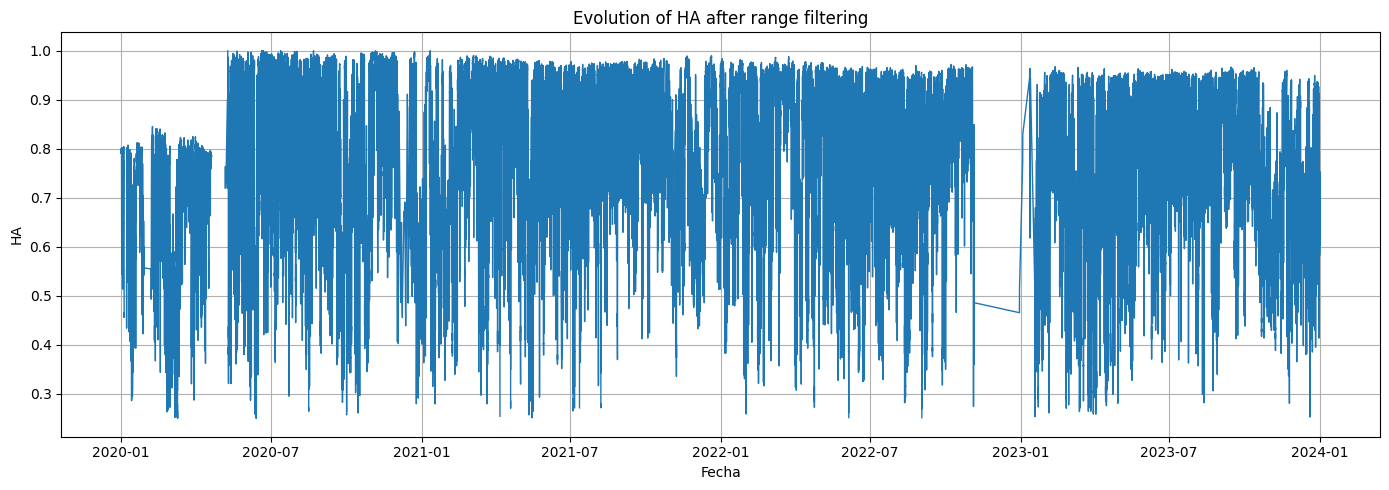

In [109]:
import matplotlib.pyplot as plt

df.index = pd.to_datetime(df.index)

plt.figure(figsize=(14,5))
plt.plot(df['instante'], df["HA"], linewidth=1)

plt.title("Evolution of HA after range filtering")
plt.xlabel("Fecha")
plt.ylabel("HA")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"images/HAout.png", dpi=300, bbox_inches="tight")

plt.show()


### TS y TA

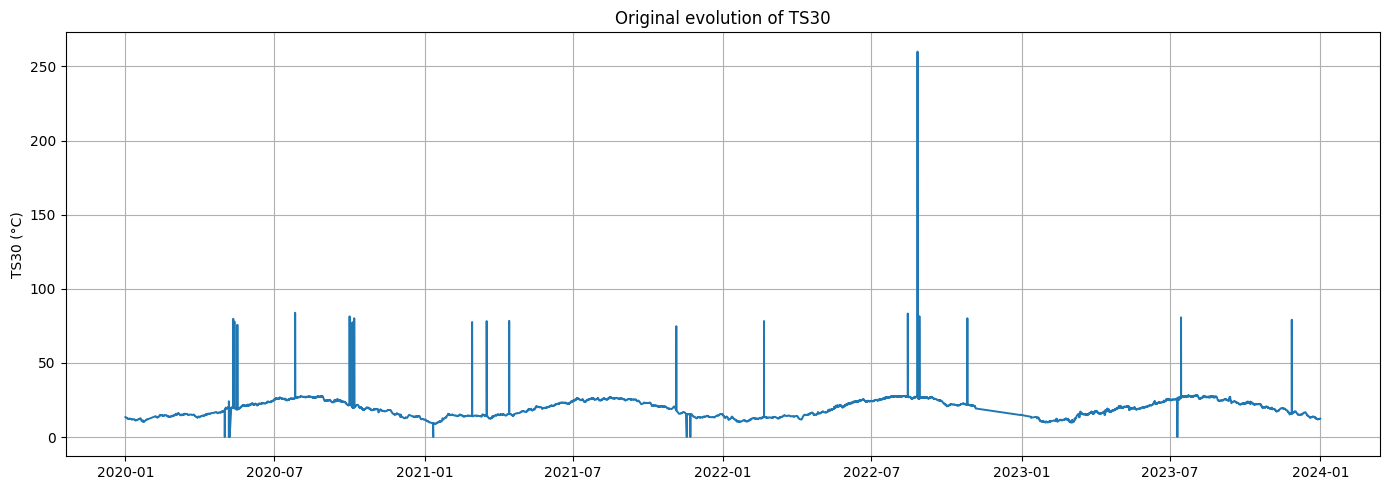

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14,5))

plt.plot(df["instante"], df["TS30"], linewidth=1.4)
plt.ylabel("TS30 (°C)")
plt.title("Original evolution of TS30")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"images/TSori.png", dpi=300, bbox_inches="tight")

plt.show()


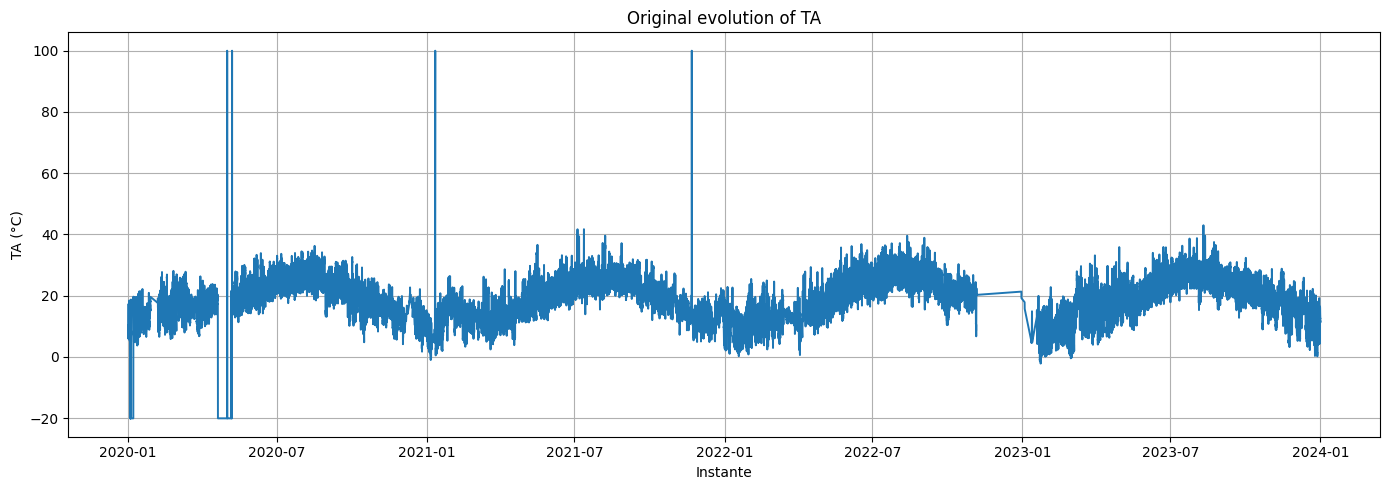

In [115]:
plt.figure(figsize=(14,5))
plt.plot(df["instante"], df["TA"], linewidth=1.4)
plt.ylabel("TA (°C)")
plt.title("Original evolution of TA")
plt.xlabel("Instante")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"images/TAori.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
n_TS30 = ((df["TS30"] < 5) | (df["TS30"] > 50)).sum()
n_TA   = ((df["TA"] < 0) | (df["TA"] > 50)).sum()

df["TS30"] = df["TS30"].mask((df["TS30"] < 5) | (df["TS30"] > 50))
df["TA"]   = df["TA"].mask((df["TA"] < 0) | (df["TA"] > 50))

print("Valores TS30 puestos a NaN:", n_TS30)
print("Valores TA puestos a NaN:", n_TA)


Valores TS30 puestos a NaN: 36
Valores TA puestos a NaN: 4847


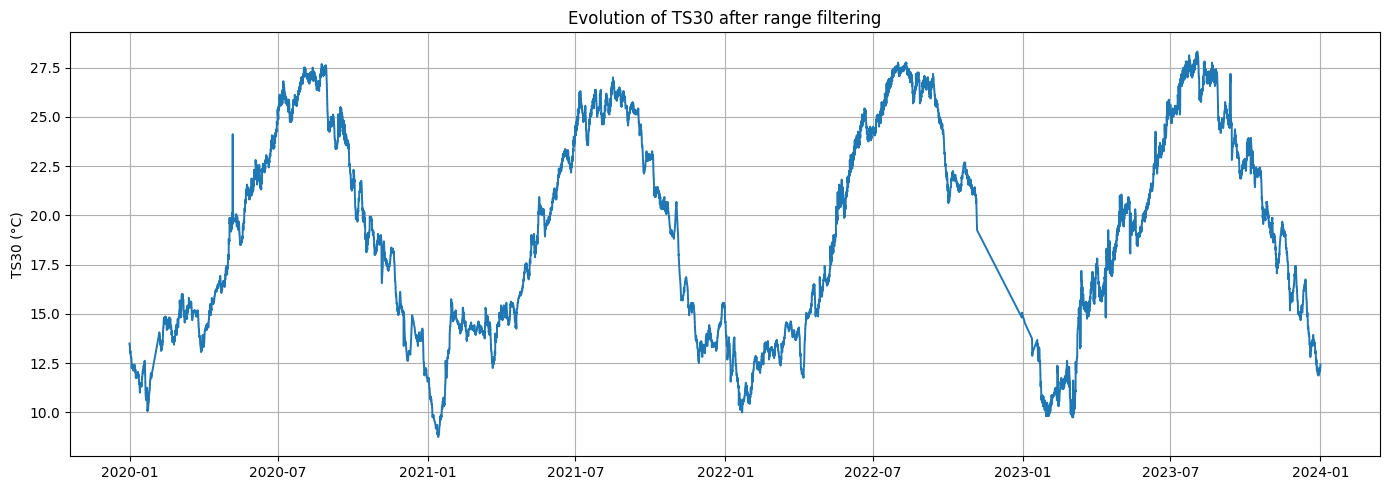

In [118]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14,5))

plt.plot(df["instante"], df["TS30"], linewidth=1.4)
plt.ylabel("TS30 (°C)")
plt.title("Evolution of TS30 after range filtering")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"images/TSout.png", dpi=300, bbox_inches="tight")

plt.show()

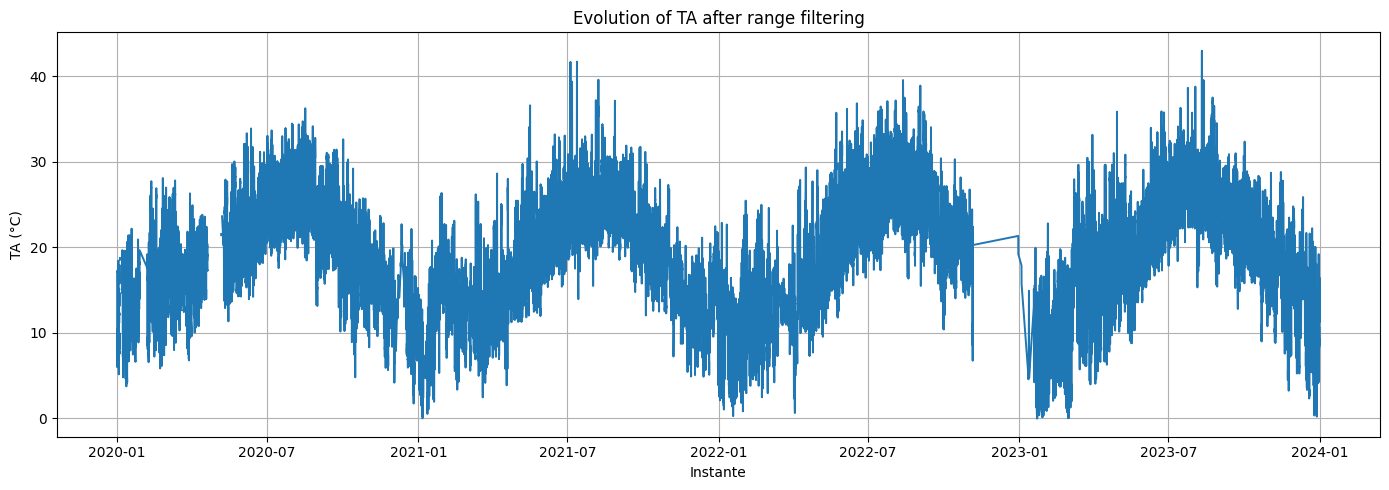

In [119]:
plt.figure(figsize=(14,5))
plt.plot(df["instante"], df["TA"], linewidth=1.4)
plt.ylabel("TA (°C)")
plt.title("Evolution of TA after range filtering")
plt.xlabel("Instante")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"images/TAout.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import pandas as pd
import numpy as np


serie = df['TS30']

q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)
iqr = q3 - q1

diffs = serie.diff().abs()
spikes = diffs > iqr*0.3

spik = spikes.sum()

df.loc[spikes, 'TS30'] = np.nan

print(f"Número de spikes eliminados (puestos a NaN) TS30: {spik}")


Número de spikes eliminados (puestos a NaN) TS30: 3


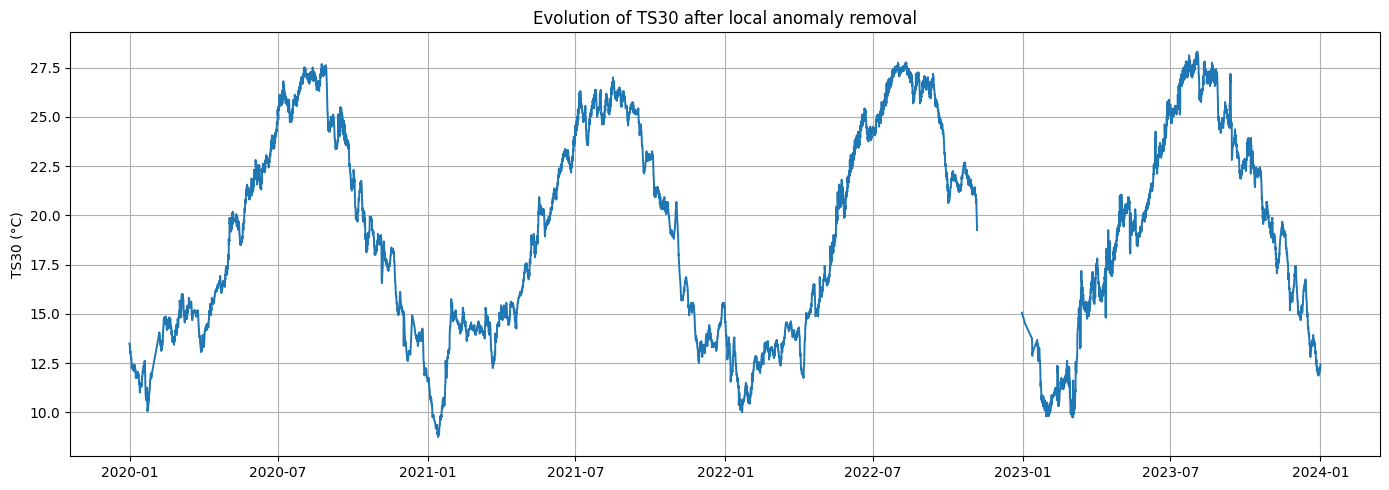

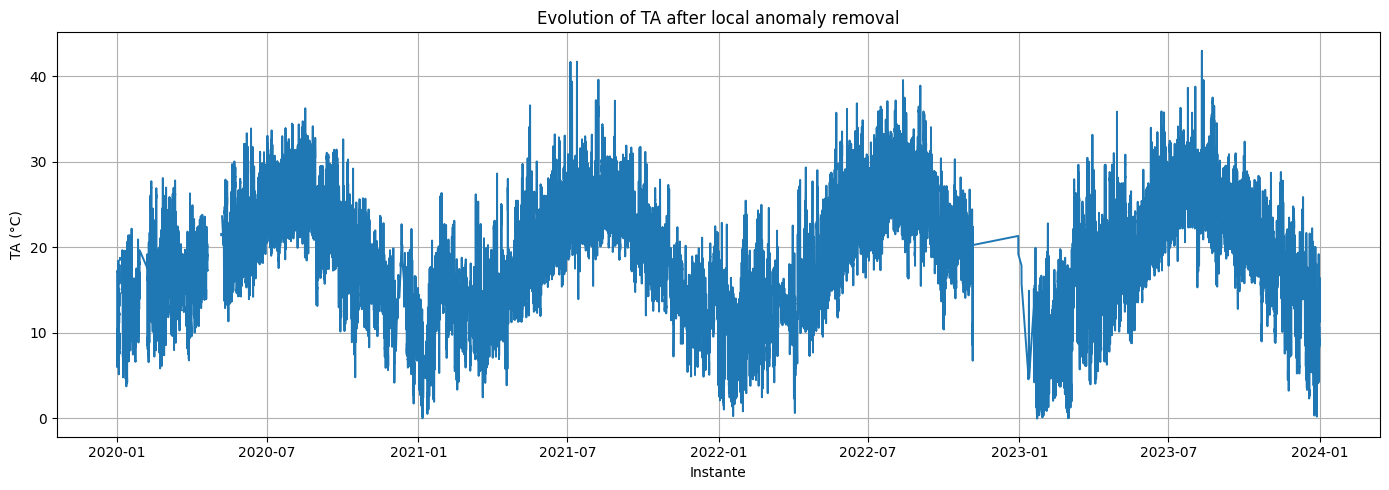

In [129]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14,5))

plt.plot(df["instante"], df["TS30"], linewidth=1.4)
plt.ylabel("TS30 (°C)")
plt.title("Evolution of TS30 after local anomaly removal")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"images/TSout2.png", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(14,5))
plt.plot(df["instante"], df["TA"], linewidth=1.4)
plt.ylabel("TA (°C)")
plt.title("Evolution of TA after local anomaly removal")
plt.xlabel("Instante")
plt.grid(True)
plt.savefig(f"images/TAout2.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


### litros_arbol

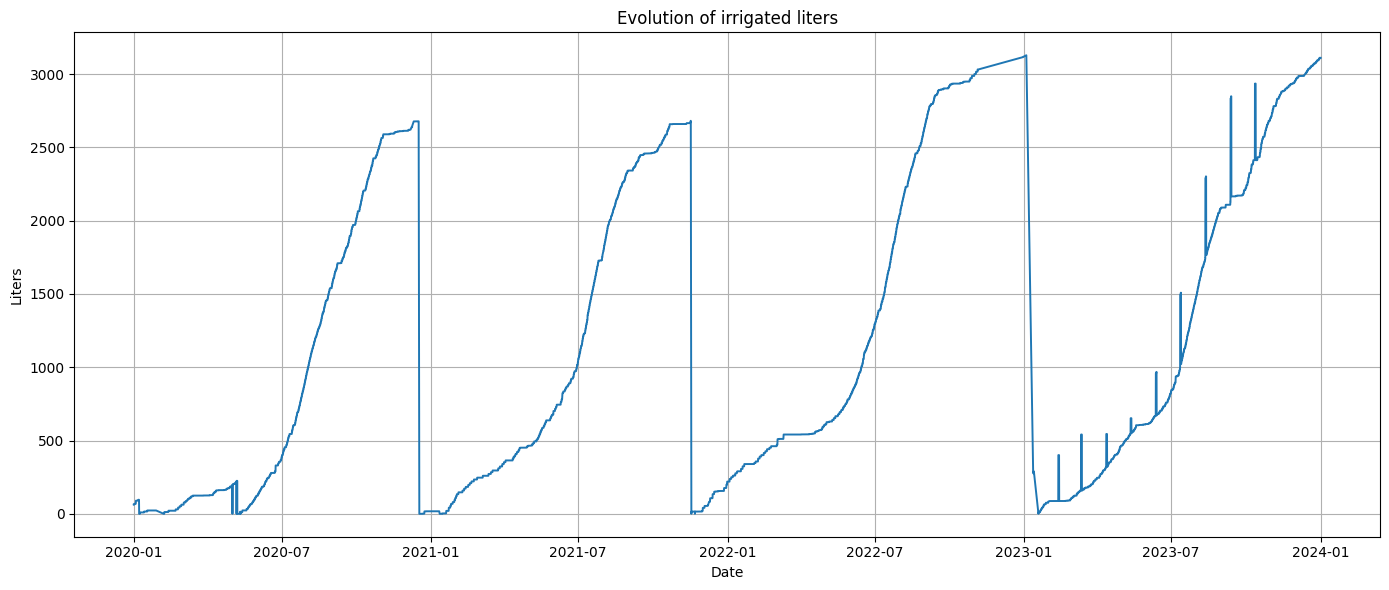

In [137]:
import matplotlib.pyplot as plt
import pandas as pd

df["instante"] = pd.to_datetime(df["instante"])

plt.figure(figsize=(14,6))
plt.plot(df["instante"], df["litros_arbol"], linewidth=1.4)

plt.xlabel("Date")
plt.ylabel("Liters")
plt.title("Evolution of irrigated liters")

plt.grid(True)
plt.tight_layout()
plt.savefig(f"images/litros.png", dpi=300, bbox_inches="tight")

plt.show()


eliminación de picos-->Nan

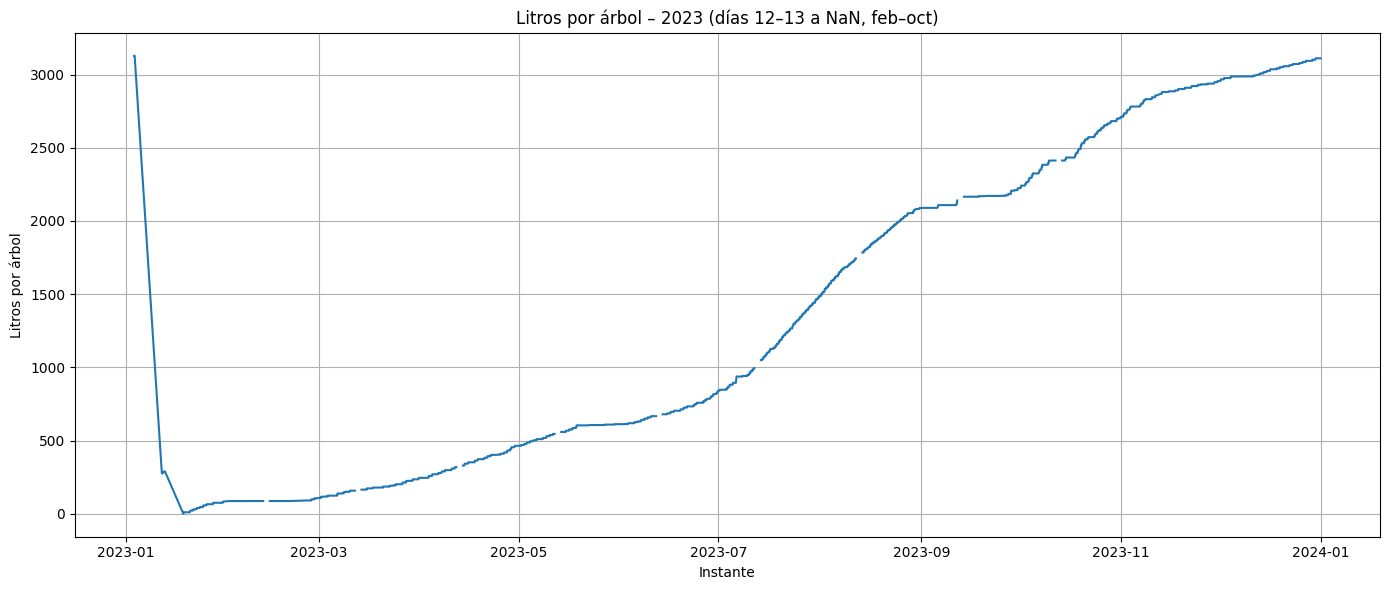

In [138]:
import numpy as np

df["instante"] = pd.to_datetime(df["instante"])

condicion_nan = (
    (df["instante"].dt.year == 2023) &
    (df["instante"].dt.month.between(2, 10)) &
    (df["instante"].dt.day.between(12, 13))
)

df.loc[condicion_nan, "litros_arbol"] = np.nan

import matplotlib.pyplot as plt

df_2023 = df[df["instante"].dt.year == 2023]

plt.figure(figsize=(14,6))
plt.plot(
    df_2023["instante"],
    df_2023["litros_arbol"],
    linewidth=1.5
)

plt.xlabel("Instante")
plt.ylabel("Litros por árbol")
plt.title("Litros por árbol – 2023 (días 12–13 a NaN, feb–oct)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df["instante"] = pd.to_datetime(df["instante"])
df = df.sort_values("instante").reset_index(drop=True)

df_meses = df[df["instante"].dt.month.between(3, 11)].reset_index(drop=True)
reinicios = df_meses[df_meses["litros_arbol"].diff() < 0]

print("Reinicios detectados en meses 3-11:")
print(reinicios[["instante", "litros_arbol"]])


Reinicios detectados en meses 3-11:
                 instante  litros_arbol
14657 2020-05-01 11:15:12      0.000000
14660 2020-05-01 11:24:33      0.000000
14662 2020-05-01 11:29:26      0.000000
14664 2020-05-01 11:34:43      0.000000
14666 2020-05-01 11:37:42      0.000000
14669 2020-05-01 11:48:15      0.000000
14671 2020-05-01 11:51:46      0.000000
14673 2020-05-01 11:57:47      0.000000
15954 2020-05-06 12:39:22      0.000000
15957 2020-05-06 12:45:47      0.000000
16208 2020-05-07 12:05:21      0.000000
16419 2020-05-11 14:04:07      0.272727
38722 2021-03-01 00:04:50    246.545455
65141 2021-11-17 09:20:29      0.272727
65617 2021-11-21 18:40:32      0.000000
90618 2023-03-01 00:04:15    108.272727


Instantes donde se corrigieron reinicios en mayo 2020:
                 instante  litros_arbol
25722 2020-05-06 12:42:05    216.818182
25976 2020-05-07 12:10:32    224.727273
26187 2020-05-11 14:13:29     14.181818


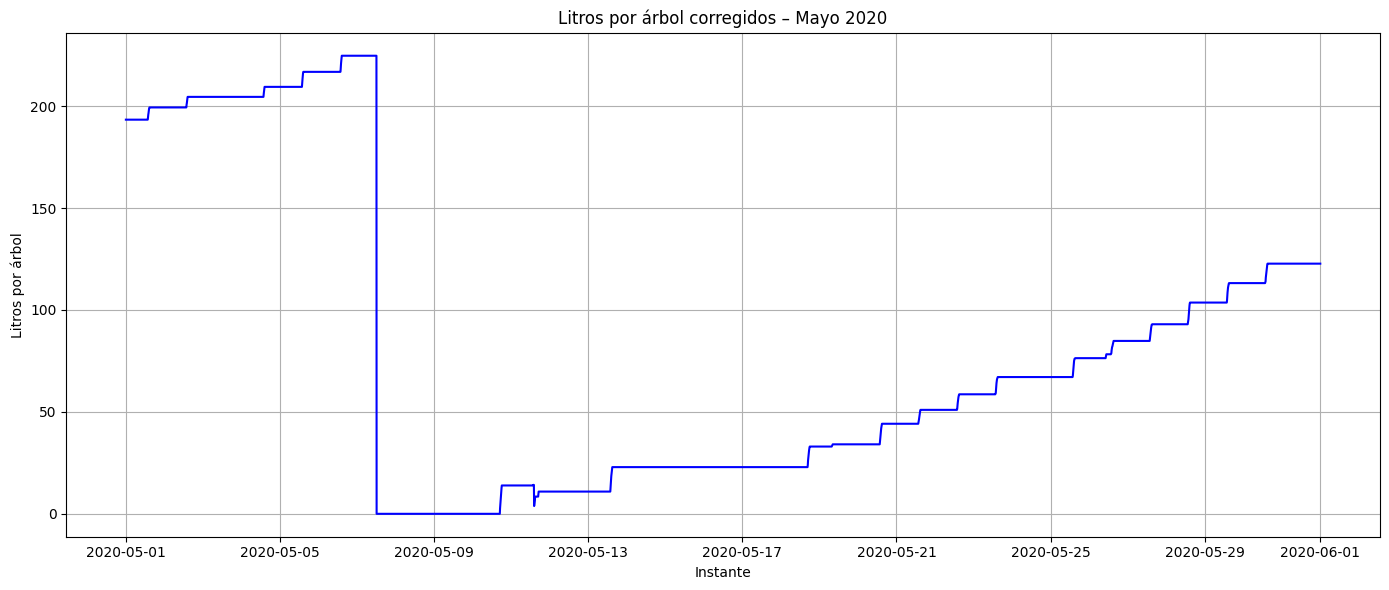

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["instante"] = pd.to_datetime(df["instante"])
df = df.sort_values("instante").reset_index(drop=True)

mask_mayo2020 = (df["instante"].dt.year == 2020) & (df["instante"].dt.month == 5)
df_mayo2020 = df[mask_mayo2020].copy()

reinicios_idx = df_mayo2020[df_mayo2020["litros_arbol"].diff() < 0].index

for idx in reinicios_idx:
    df.loc[idx, "litros_arbol"] = df.loc[idx-1, "litros_arbol"]

print("Instantes donde se corrigieron reinicios en mayo 2020:")
print(df.loc[reinicios_idx, ["instante", "litros_arbol"]])

plt.figure(figsize=(14, 6))
plt.plot(df.loc[mask_mayo2020, "instante"],
         df.loc[mask_mayo2020, "litros_arbol"],
         color='blue', linewidth=1.5)
plt.xlabel("Instante")
plt.ylabel("Litros por árbol")
plt.title("Litros por árbol corregidos – Mayo 2020")
plt.grid(True)
plt.tight_layout()
plt.show()


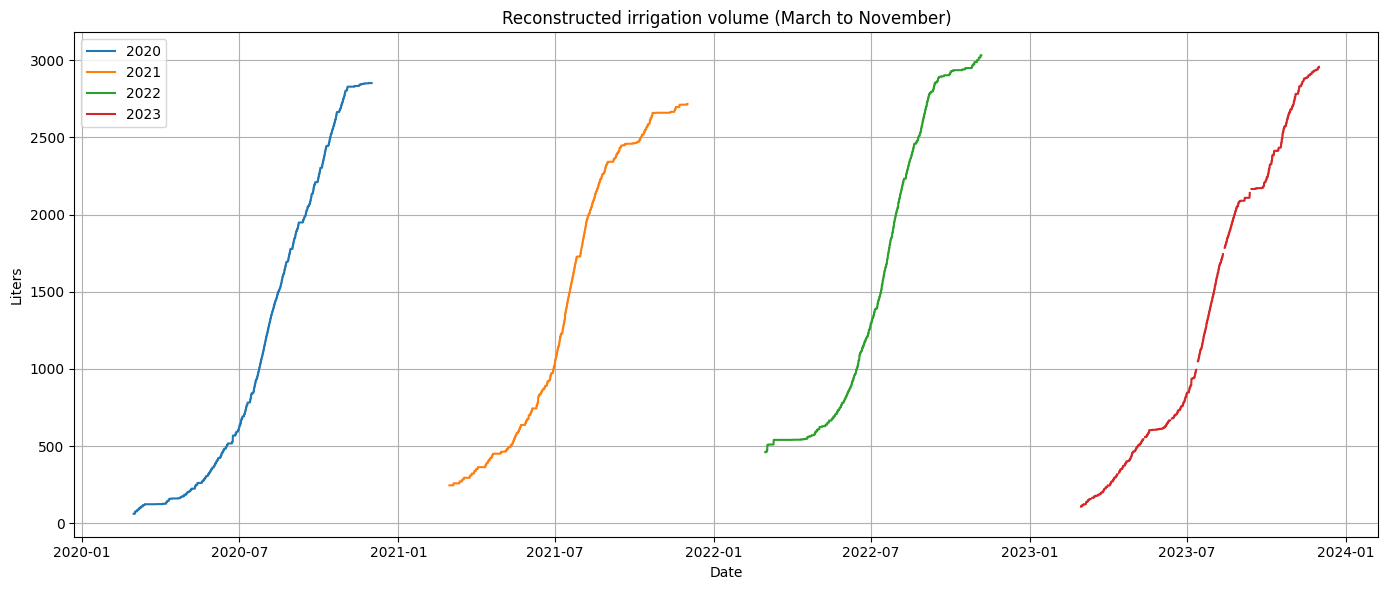

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["instante"] = pd.to_datetime(df["instante"])
df = df.sort_values("instante").reset_index(drop=True)

def reconstruir_litros(df_subset):
    offset = 0.0
    prev = None
    litros_corregidos = []

    for current in df_subset["litros_arbol"]:
        if prev is None:
            litros_corregidos.append(current)
        else:
            if current < prev:
                offset += prev
            litros_corregidos.append(current + offset)
        prev = current

    df_subset["litros_arbol"] = litros_corregidos
    return df_subset

for year in range(2020, 2024):
    mask = (df["instante"].dt.year == year) & (df["instante"].dt.month.between(3, 11))
    df.loc[mask] = reconstruir_litros(df.loc[mask].copy())

plt.figure(figsize=(14, 6))
for year in range(2020, 2024):
    df_year = df[(df["instante"].dt.year == year) & (df["instante"].dt.month.between(3, 11))]
    plt.plot(df_year["instante"], df_year["litros_arbol"], label=str(year), linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Liters")
plt.title("Reconstructed irrigation volume (March to November)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"images/litrosRe.png", dpi=300, bbox_inches="tight")
plt.show()


### Resumen de nulos

In [ ]:
import pandas as pd

df["instante"] = pd.to_datetime(df["instante"])

if "año" not in df.columns:
    df["año"] = df["instante"].dt.year

cols_interes = [col for col in df.columns if col.startswith("HS")] + ["HA", "TS30", "TA", "litros_arbol"]

# Contar nulos por variable y año
nulos_por_var_año = df.groupby("año")[cols_interes].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año:")
print(nulos_por_var_año)

# Contar nulos totales por variable en todo el DataFrame
nulos_totales = df[cols_interes].isna().sum()
print("\nNúmero total de valores nulos por variable:")
print(nulos_totales)


Número de valores nulos por variable y año:
      HS10  HS20  HS30  HS40  HS50  HS60    HA  TS30    TA  litros_arbol
año                                                                     
2020    15    15    15    16    15    15  4889    22  4768             0
2021     4     4     4     4     4     4    35     8    26             0
2022     6     6     0     1     0     0     3     6     0             0
2023     0     1     0     0     0     0    36     3    53          1971

Número total de valores nulos por variable:
HS10              25
HS20              26
HS30              19
HS40              21
HS50              19
HS60              19
HA              4963
TS30              39
TA              4847
litros_arbol    1971
dtype: int64


### Detectar duplicados

In [ ]:
import pandas as pd

duplicados = df[df.duplicated(subset=["id_nodo", "instante"], keep=False)]

instantes_duplicados = (
    duplicados
    .groupby(["id_nodo", "instante"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

print("Instantes duplicados:")
print(instantes_duplicados)

print("\nFilas duplicadas completas:")
print(duplicados.sort_values(["id_nodo", "instante"]))


Instantes duplicados:
   id_nodo            instante  count
0        2 2020-03-08 03:00:00      7
1        2 2021-03-14 03:00:00      6
2        2 2022-03-13 03:00:00      7

Filas duplicadas completas:
       id_nodo            instante    HS10    HS20    HS30    HS40    HS50  \
11277        2 2020-03-08 03:00:00  0.7290  0.7590  0.7757  0.7830  0.7894   
11278        2 2020-03-08 03:00:00  0.7290  0.7590  0.7757  0.7830  0.7894   
11279        2 2020-03-08 03:00:00  0.7290  0.7590  0.7755  0.7830  0.7894   
11280        2 2020-03-08 03:00:00  0.7288  0.7593  0.7757  0.7830  0.7894   
11281        2 2020-03-08 03:00:00  0.7291  0.7596  0.7757  0.7832  0.7897   
11282        2 2020-03-08 03:00:00  0.7294  0.7596  0.7757  0.7835  0.7897   
11283        2 2020-03-08 03:00:00  0.7285  0.7593  0.7757  0.7832  0.7894   
57784        2 2021-03-14 03:00:00  0.6980  0.7493  0.7741  0.7735  0.7804   
57785        2 2021-03-14 03:00:00  0.6980  0.7493  0.7741  0.7735  0.7801   
57786        2 20

Como son valores válidos y muy similares, elimino sacando promedio

In [ ]:
import pandas as pd

duplicados = df[df.duplicated(subset=["id_nodo", "instante"], keep=False)]

cols_numericas = duplicados.select_dtypes(include='number').columns.tolist()

for col in ["año", "id_nodo"]:
    if col in cols_numericas:
        cols_numericas.remove(col)

prom_media = (
    duplicados
    .groupby(["id_nodo", "instante"], as_index=False)[cols_numericas]
    .mean()
)

no_media = (
    duplicados
    .groupby(["id_nodo", "instante"], as_index=False)[["año", "id_nodo"]]
    .first()
)

promedios = pd.merge(prom_media, no_media, on=["id_nodo", "instante"])

print("Registros promedio generados:")
print(promedios)

df = df.drop_duplicates(subset=["id_nodo", "instante"], keep=False)

# Unir DF sin duplicados + los promedios
df = pd.concat([df, promedios], ignore_index=True)


Registros promedio generados:
   id_nodo            instante      HS10      HS20      HS30      HS40  \
0        2 2020-03-08 03:00:00  0.728971  0.759257  0.775671  0.783129   
1        2 2021-03-14 03:00:00  0.697600  0.749300  0.774033  0.773500   
2        2 2022-03-13 03:00:00  0.766900  0.755971  0.780100  0.776357   

       HS50      HS60   TS30        TA        HA  litros_arbol   año  
0  0.789486  0.804086  15.00  9.935714  0.701857    102.000000  2020  
1  0.780350  0.797500  14.93  7.145000  0.955933    271.909091  2021  
2  0.783729  0.799086  13.62  9.058571  0.841186    540.818182  2022  


Seleccionamos meses de interés (marzo-noviembre)

In [ ]:
df["instante"] = pd.to_datetime(df["instante"])

dft = df[df["instante"].dt.month.between(3, 11)]

dft.to_csv("LaClosaT.csv", index=False)

## Estadísticas intervalos entre registros

In [1]:
import pandas as pd
dft = pd.read_csv("csv\LaClosaT.csv")

<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_18188\2258718882.py:2: SyntaxWarning: invalid escape sequence '\L'
  dft = pd.read_csv("csv\LaClosaT.csv")


In [2]:
dft['instante'] = pd.to_datetime(dft['instante'], errors='coerce')

dft = dft.sort_values('instante').reset_index(drop=True)

dft['diff'] = dft['instante'].diff()

tiempo_min   = dft['diff'].min()

tiempo_max   = dft[dft['diff'] <= pd.Timedelta(days=90)]['diff'].max()

tiempo_mediana = dft['diff'].median()

print("Tiempo mínimo entre registros:", tiempo_min)
print("Tiempo máximo entre registros:", tiempo_max)
print("Tiempo mediana entre registros:", tiempo_mediana)


Tiempo mínimo entre registros: 0 days 00:00:02
Tiempo máximo entre registros: 1 days 22:25:39
Tiempo mediana entre registros: 0 days 00:09:21


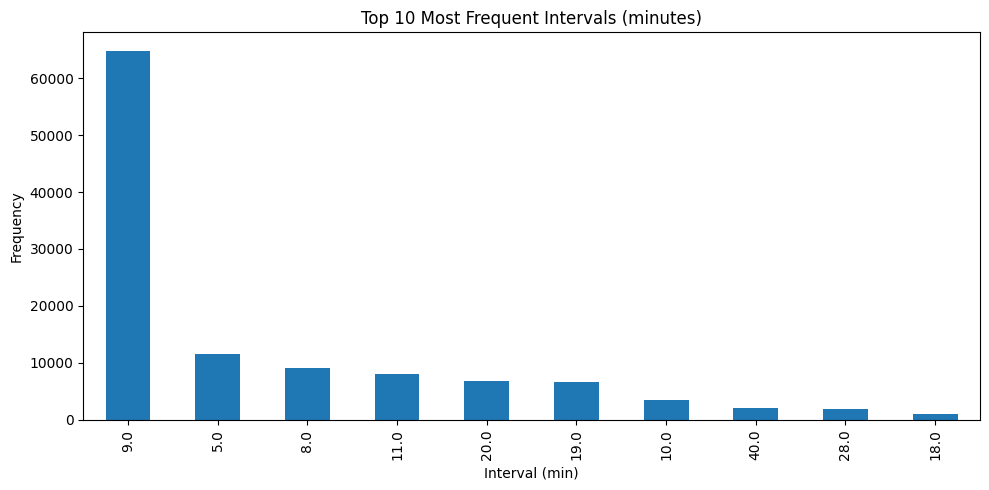

In [ ]:
import matplotlib.pyplot as plt

intervalos_min = (dft['instante'].diff().dt.total_seconds() / 60).round(0)
top10 = intervalos_min[1:].value_counts().head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title("Top 10 Most Frequent Intervals (minutes)")
plt.xlabel("Interval (min)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"images/interval.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
dft = dft.sort_values('instante').copy()

dft['diff'] = dft['instante'].shift(-1) - dft['instante']

dft_filtrado = dft[dft['diff'] <= pd.Timedelta(days=90)]

saltos_24h = (dft_filtrado['diff'] > pd.Timedelta(hours=24)).sum()
saltos_2h  = (dft_filtrado['diff'] > pd.Timedelta(hours=2)).sum()
saltos_1h  = (dft_filtrado['diff'] > pd.Timedelta(hours=1)).sum()

print("Saltos > 24h (≤3 meses):", saltos_24h)
print("Saltos > 2h  (≤3 meses):", saltos_2h)
print("Saltos > 1h  (≤3 meses):", saltos_1h)

saltos_24h_df = dft_filtrado[dft_filtrado['diff'] > pd.Timedelta(hours=24)].copy()

saltos_24h_df['inicio'] = saltos_24h_df['instante']
saltos_24h_df['fin'] = saltos_24h_df['instante'].shift(-1)
saltos_24h_df['duracion_horas'] = saltos_24h_df['diff'].dt.total_seconds() / 3600

resultado = saltos_24h_df[['inicio', 'fin', 'duracion_horas']]

print(resultado)


Saltos > 24h (≤3 meses): 6
Saltos > 2h  (≤3 meses): 69
Saltos > 1h  (≤3 meses): 1215
                    inicio                 fin  duracion_horas
16204  2020-05-07 12:16:51 2021-07-30 23:57:35       46.427500
56074  2021-07-30 23:57:35 2021-10-07 23:55:27       24.063333
63270  2021-10-07 23:55:27 2021-10-22 01:07:42       24.121944
64493  2021-10-22 01:07:42 2021-11-07 18:10:11       32.719167
64966  2021-11-07 18:10:11 2023-11-11 23:06:47       39.769444
120136 2023-11-11 23:06:47                 NaT       24.963889


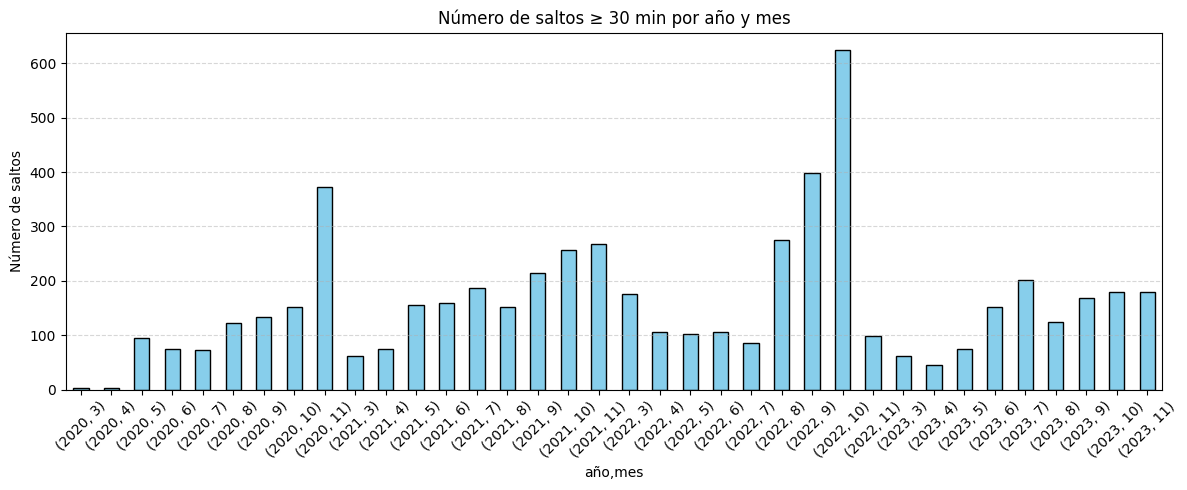

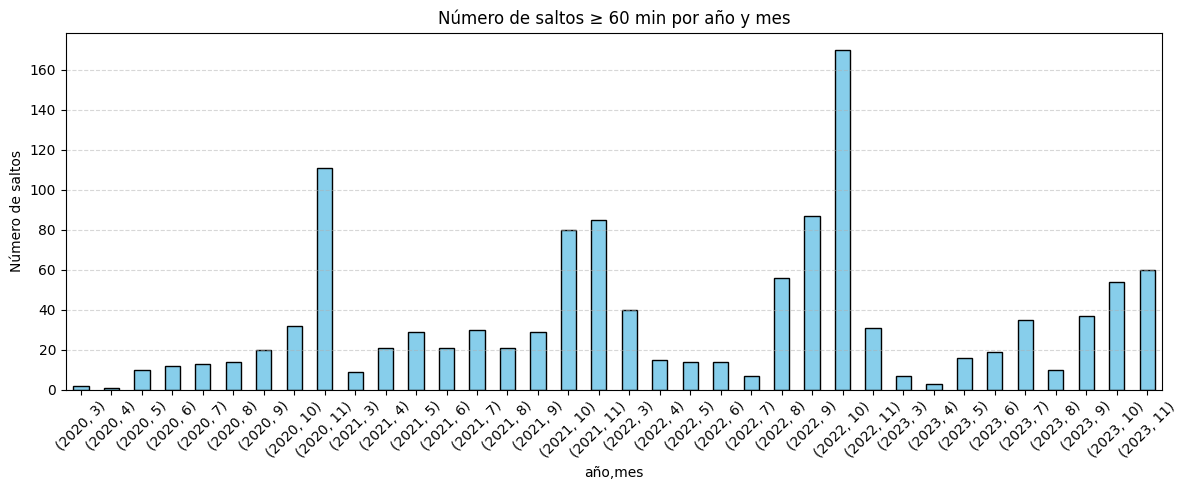

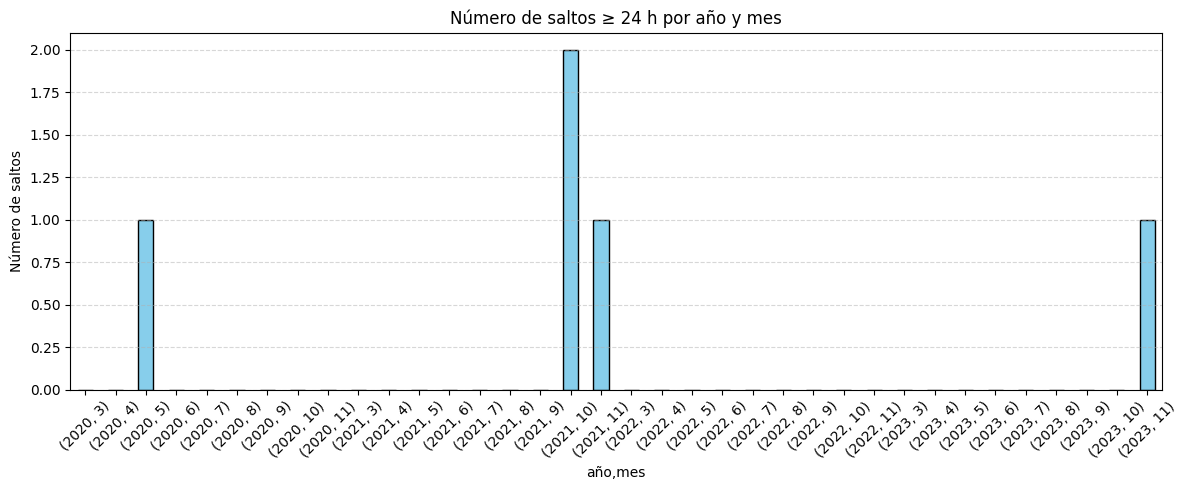

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dft_plot = dft.sort_values('instante').copy()
dft_plot['instante'] = pd.to_datetime(dft_plot['instante'])

dft_plot = dft_plot[dft_plot['instante'].dt.month.between(3, 11)].copy()

dft_plot['año'] = dft_plot['instante'].dt.year
dft_plot['mes'] = dft_plot['instante'].dt.month

dft_plot['diff'] = dft_plot.groupby(['año','mes'])['instante'].diff()
dft_plot['diff_minutos'] = dft_plot['diff'].dt.total_seconds() / 60

umbrales = [30, 60, 24*60]  # minutos
nombres = ['30 min', '60 min', '24 h']

saltos_por_umbral = pd.DataFrame()

for umbral, nombre in zip(umbrales, nombres):
    df_salto = dft_plot[dft_plot['diff_minutos'] >= umbral].groupby(['año','mes']).size().reset_index(name=nombre)
    if saltos_por_umbral.empty:
        saltos_por_umbral = df_salto
    else:
        saltos_por_umbral = saltos_por_umbral.merge(df_salto, on=['año','mes'], how='outer')

saltos_por_umbral = saltos_por_umbral.fillna(0).sort_values(['año','mes']).reset_index(drop=True)
saltos_por_umbral.set_index(['año','mes'], inplace=True)

for nombre in nombres:
    plt.figure(figsize=(12,5))
    saltos_por_umbral[nombre].plot(kind='bar', color='skyblue', edgecolor='black')
    plt.ylabel("Número de saltos")
    plt.title(f"Número de saltos ≥ {nombre} por año y mes")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


Dias consecutivos sin saltos

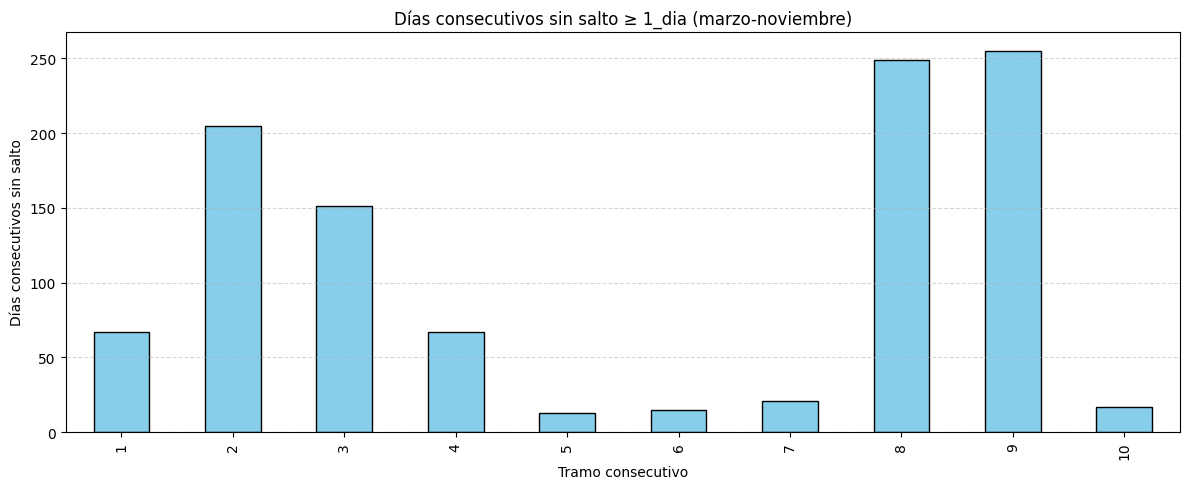

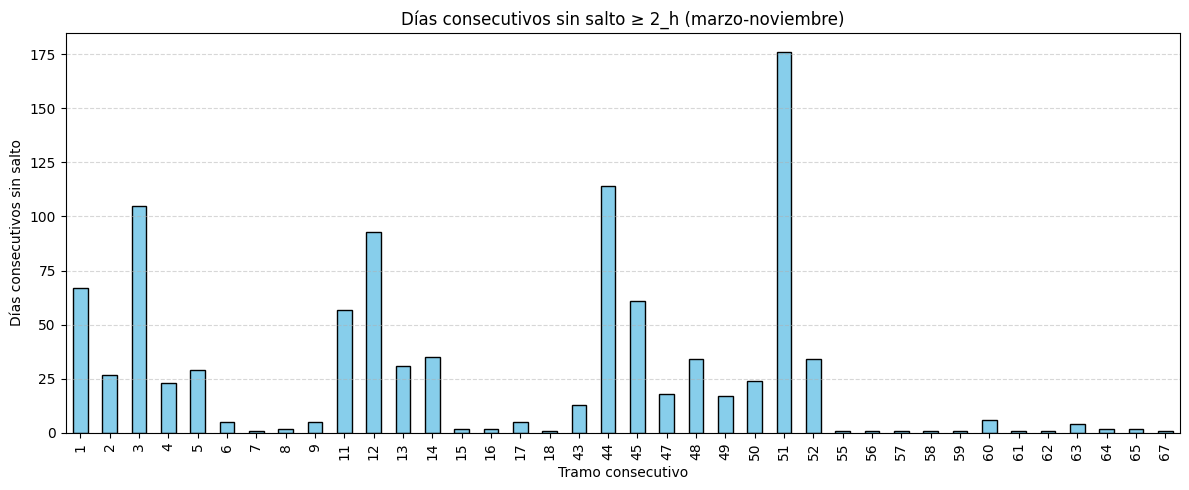

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dft_plot = dft.sort_values('instante').copy()
dft_plot['instante'] = pd.to_datetime(dft_plot['instante'])
dft_plot['año'] = dft_plot['instante'].dt.year
dft_plot['mes'] = dft_plot['instante'].dt.month
dft_plot['día'] = dft_plot['instante'].dt.date

dft_plot = dft_plot[dft_plot['mes'].between(3, 11)].copy()

dft_plot['diff_minutos'] = dft_plot['instante'].diff().dt.total_seconds() / 60

umbrales = {'1_dia': 1440, '2_h': 120}
for nombre, umbral in umbrales.items():
    dft_plot[f'salto_{nombre}'] = (dft_plot['diff_minutos'] >= umbral) | (dft_plot['diff_minutos'].isna())

dias_consecutivos = {}

for nombre, umbral in umbrales.items():
    df_dia = dft_plot.groupby(['año','día'])[f'salto_{nombre}'].any().reset_index()
    
    df_dia['sin_salto'] = (~df_dia[f'salto_{nombre}']).astype(int)
    
    df_dia['grupo'] = (df_dia['sin_salto'] == 0).cumsum()  # reinicia cuando hay salto
    consecutivos = df_dia[df_dia['sin_salto']==1].groupby('grupo').size()
    
    dias_consecutivos[nombre] = consecutivos

for nombre, series in dias_consecutivos.items():
    plt.figure(figsize=(12,5))
    series.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.ylabel("Días consecutivos sin salto")
    plt.xlabel("Tramo consecutivo")
    plt.title(f"Días consecutivos sin salto ≥ {nombre} (marzo-noviembre)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
